In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Chargement et merge ──────────────────────────────────────────────────────
rel = pd.read_csv('iris/iris_religion_assoc.csv', dtype={'IRIS': str}, low_memory=False)
rel['IRIS'] = rel['IRIS'].str.zfill(9)

socio = pd.read_csv('iris/iris_final_socio_politique.csv', dtype={'IRIS': str}, low_memory=False)
socio['IRIS'] = socio['IRIS'].str.zfill(9)

df = socio.merge(rel, on='IRIS', how='left')

# Colonnes utiles
POUR1000 = [c for c in rel.columns if c.endswith('_pour1000')]
RAW_RNA  = [c for c in rel.columns if c.startswith('rna_') and not c.endswith('_pour1000')]
RAW_BPE  = [c for c in rel.columns if c.startswith('nb_') or (c.startswith('bpe_') and not c.endswith('_pour1000'))]

SCORES_SOCIO = ['score_cap_eco', 'score_cap_cult', 'score_domination', 'score_exploitation',
                 'score_precarite', 'score_ruralite', 'score_urbanite', 'score_confort_residentiel']
PCT_SOCIO    = ['pct_csp_plus', 'pct_csp_ouvrier', 'pct_chomage', 'pct_immigres',
                'pct_sans_diplome', 'pct_bac_plus', 'pct_hlm', 'pct_proprietaires',
                'DISP_TP6021', 'DISP_MED21']

print(f"Dataset mergé : {df.shape[0]} IRIS × {df.shape[1]} colonnes")
print(f"  Colonnes /1000 : {len(POUR1000)}")
print(f"  Colonnes RNA brutes : {len(RAW_RNA)}")
print(f"\nIRIS avec au moins 1 association culte (total) : {(df['rna_culte_total'] > 0).sum()}")
print(f"IRIS avec au moins 1 lieu de culte BPE       : {(df['nb_lieux_culte_bpe'] > 0).sum()}")


Dataset mergé : 49303 IRIS × 493 colonnes
  Colonnes /1000 : 16
  Colonnes RNA brutes : 14

IRIS avec au moins 1 association culte (total) : 16526
IRIS avec au moins 1 lieu de culte BPE       : 17767


# EDA — Variables religion & associations (iris_religion_assoc.csv)

## 1. Vue d'ensemble — statistiques descriptives


In [11]:
# ── 1. Statistiques descriptives des colonnes /1000 ─────────────────────────
desc = df[POUR1000].describe(percentiles=[.25, .5, .75, .90, .95, .99]).T
desc['% IRIS > 0'] = (df[POUR1000] > 0).mean() * 100
desc['% IRIS = 0'] = (df[POUR1000] == 0).mean() * 100
desc['% NaN']      = df[POUR1000].isna().mean() * 100
display(desc[['count','mean','std','min','25%','50%','75%','90%','95%','99%','max','% IRIS > 0','% NaN']].round(3))


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max,% IRIS > 0,% NaN
nb_lieux_culte_bpe_pour1000,48079.0,0.513,1.116,0.0,0.0,0.000,0.540,1.550,2.681,6.667,6.667,35.933,2.483
bpe_grande_surface_pour1000,48079.0,1.650,2.424,0.0,0.0,0.862,2.294,4.342,6.376,13.546,13.547,57.751,2.483
rna_culte_total_pour1000,48079.0,0.347,0.834,0.0,0.0,0.000,0.354,1.077,1.818,5.348,5.348,33.270,2.483
rna_culte_chretien_total_pour1000,48079.0,0.251,0.646,0.0,0.0,0.000,0.104,0.797,1.390,4.185,4.188,29.939,2.483
rna_culte_catholique_pour1000,48079.0,0.074,0.285,0.0,0.0,0.000,0.000,0.082,0.477,2.037,2.037,16.206,2.483
rna_culte_evangelique_pour1000,48079.0,0.074,0.238,0.0,0.0,0.000,0.000,0.282,0.537,1.484,1.484,17.129,2.483
rna_culte_protestant_pour1000,48079.0,0.025,0.116,0.0,0.0,0.000,0.000,0.000,0.060,0.806,0.807,8.746,2.483
rna_culte_orthodoxe_pour1000,48079.0,0.001,0.007,0.0,0.0,0.000,0.000,0.000,0.000,0.062,0.062,3.036,2.483
rna_culte_islam_pour1000,48079.0,0.023,0.103,0.0,0.0,0.000,0.000,0.000,0.119,0.672,0.672,9.567,2.483
rna_culte_juif_pour1000,48079.0,0.007,0.051,0.0,0.0,0.000,0.000,0.000,0.000,0.424,0.424,3.874,2.483


## 2. Distributions des variables /1000 (histogrammes)

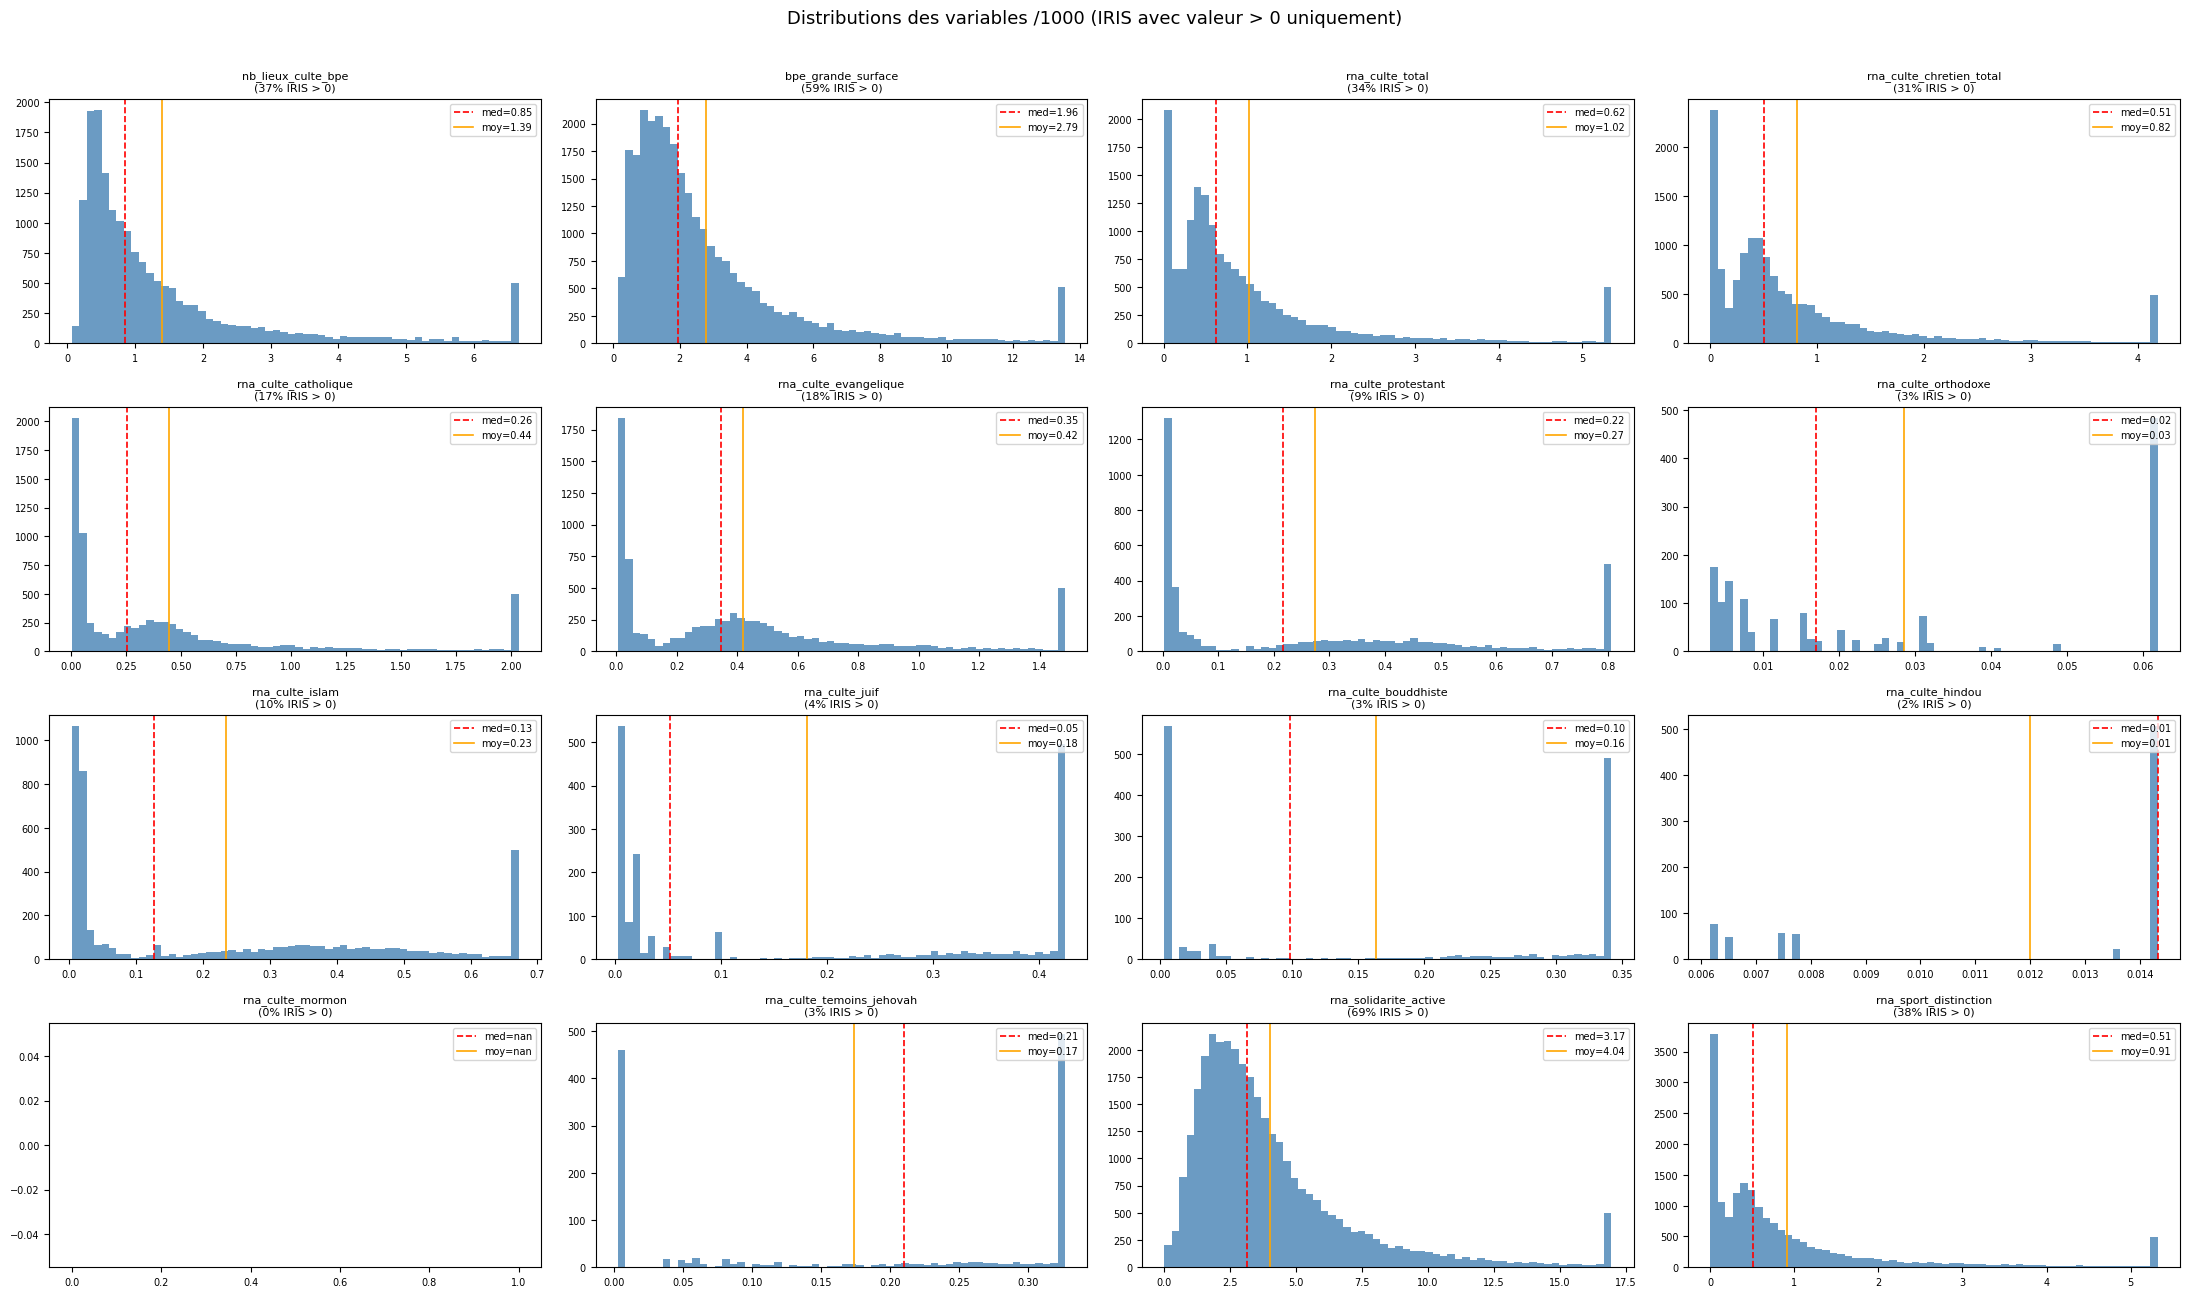

In [12]:
# ── 2. Histogrammes /1000 ────────────────────────────────────────────────────
# Seulement les IRIS avec valeur > 0 pour mieux voir la distribution réelle
n = len(POUR1000)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 3.2))
axes = axes.flatten()

for i, col in enumerate(POUR1000):
    ax = axes[i]
    vals = df[col].dropna()
    nonzero = vals[vals > 0]
    ax.hist(nonzero, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
    ax.axvline(nonzero.median(), color='red', lw=1.2, ls='--', label=f'med={nonzero.median():.2f}')
    ax.axvline(nonzero.mean(),   color='orange', lw=1.2, ls='-', label=f'moy={nonzero.mean():.2f}')
    pct_nonzero = 100 * len(nonzero) / len(vals) if len(vals) > 0 else 0
    ax.set_title(f'{col.replace("_pour1000","")}\n({pct_nonzero:.0f}% IRIS > 0)', fontsize=8)
    ax.legend(fontsize=7, loc='upper right')
    ax.tick_params(labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distributions des variables /1000 (IRIS avec valeur > 0 uniquement)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 3. Couverture géographique — % IRIS couverts par religion

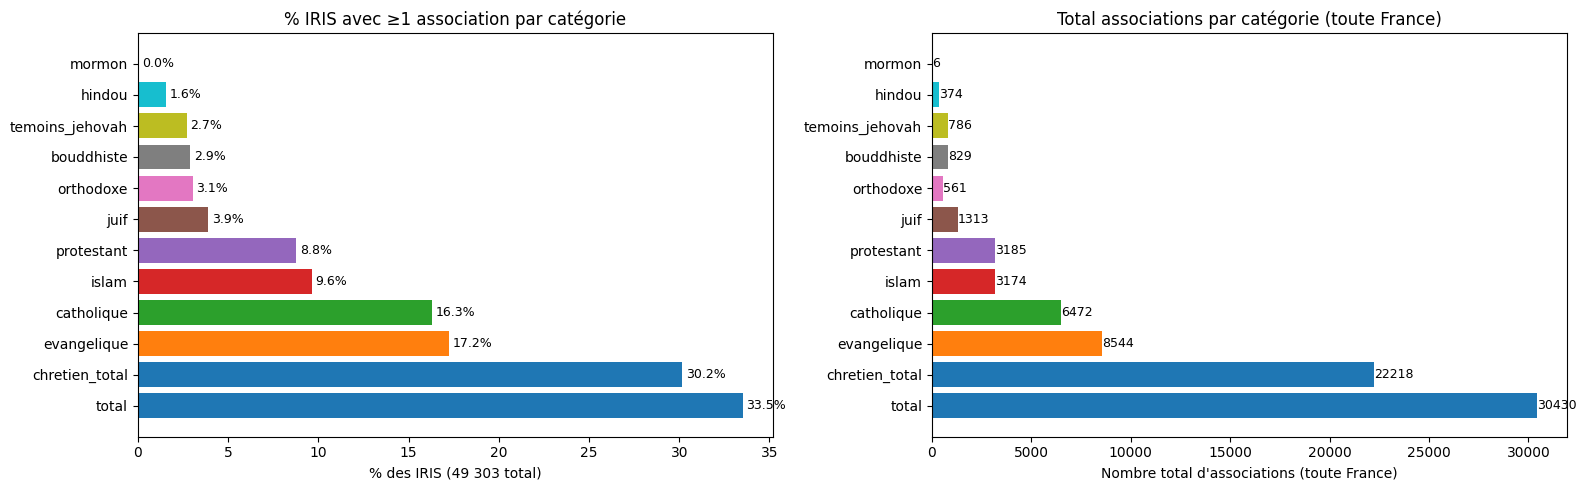

      Catégorie  IRIS couverts  % IRIS couverts  Total assoc (somme)
          total          16526        33.519258              30430.0
 chretien_total          14869        30.158408              22218.0
    evangelique           8504        17.248443               8544.0
     catholique           8046        16.319494               6472.0
          islam           4754         9.642415               3174.0
     protestant           4328         8.778370               3185.0
           juif           1922         3.898343               1313.0
      orthodoxe           1505         3.052553                561.0
     bouddhiste           1428         2.896375                829.0
temoins_jehovah           1340         2.717887                786.0
         hindou            776         1.573941                374.0
         mormon              6         0.012170                  6.0


In [13]:
# ── 3. Couverture : % IRIS avec au moins une asso par catégorie ───────────────
rna_raw_culte = [c for c in RAW_RNA if 'culte' in c]
coverage = pd.DataFrame({
    'Catégorie': [c.replace('rna_culte_', '') for c in rna_raw_culte],
    'IRIS couverts': [(df[c] > 0).sum() for c in rna_raw_culte],
    '% IRIS couverts': [(df[c] > 0).mean() * 100 for c in rna_raw_culte],
    'Total assoc (somme)': [df[c].sum() for c in rna_raw_culte],
}).sort_values('IRIS couverts', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot % IRIS couverts
colors = plt.cm.tab10(np.linspace(0, 1, len(coverage)))
bars = axes[0].barh(coverage['Catégorie'], coverage['% IRIS couverts'], color=colors)
axes[0].set_xlabel('% des IRIS (49 303 total)')
axes[0].set_title('% IRIS avec ≥1 association par catégorie')
for bar, val in zip(bars, coverage['% IRIS couverts']):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)

# Total associations
bars2 = axes[1].barh(coverage['Catégorie'], coverage['Total assoc (somme)'], color=colors)
axes[1].set_xlabel('Nombre total d\'associations (toute France)')
axes[1].set_title('Total associations par catégorie (toute France)')
for bar, val in zip(bars2, coverage['Total assoc (somme)']):
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()
print(coverage.to_string(index=False))


## 4. Corrélations entre variables /1000 (heatmap)

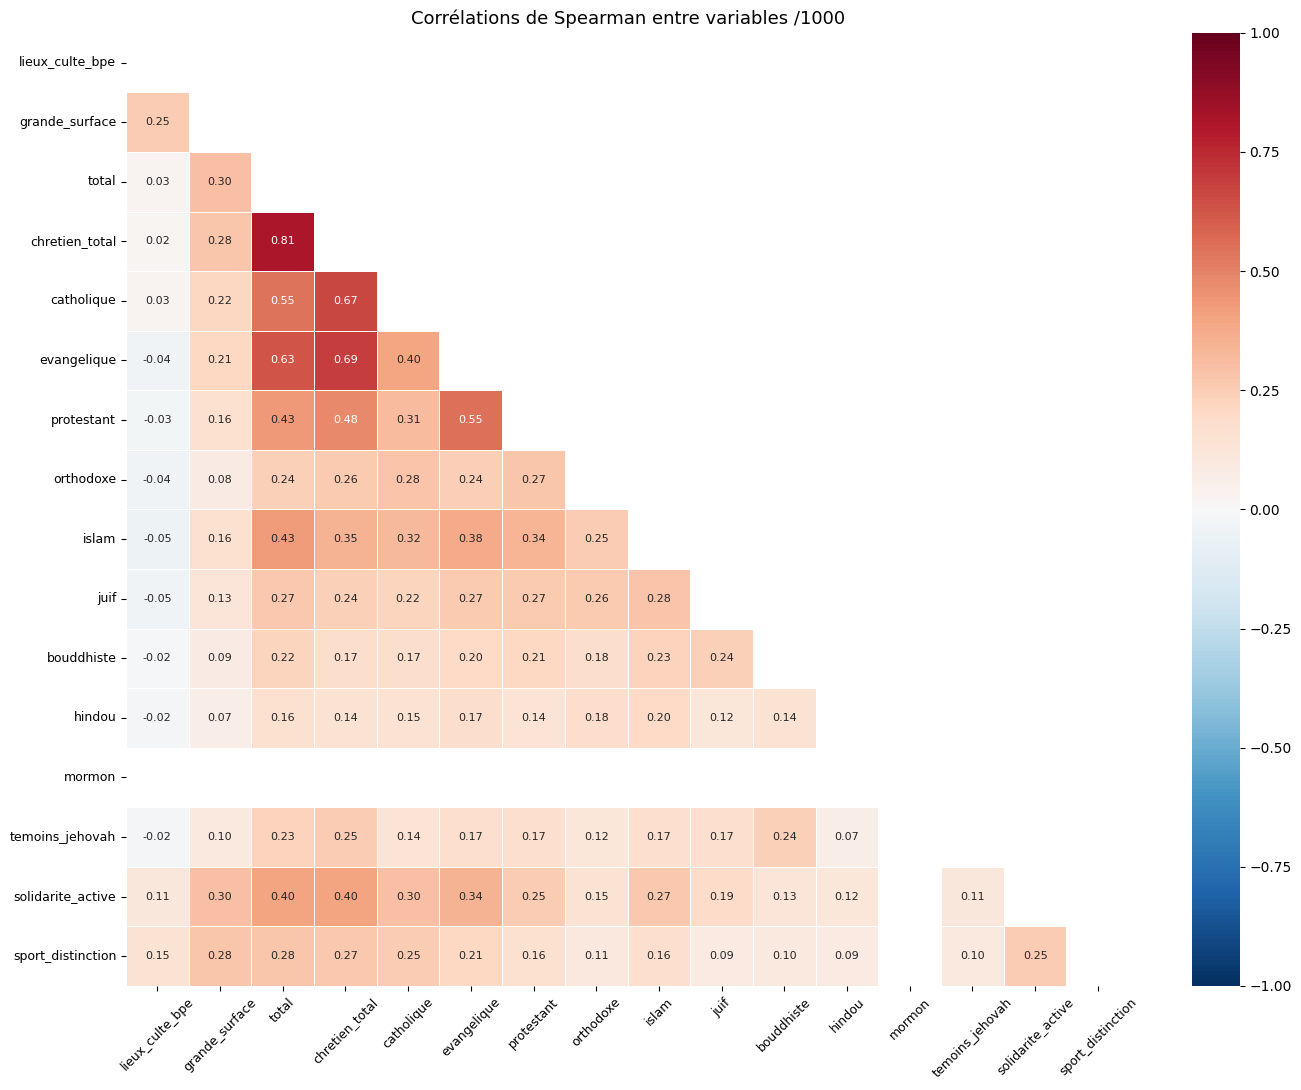

In [14]:
# ── 4. Heatmap de corrélations entre toutes les variables /1000 ──────────────
corr = df[POUR1000].corr(method='spearman')
labels = [c.replace('_pour1000','').replace('rna_culte_','').replace('rna_','').replace('nb_','').replace('bpe_','') for c in POUR1000]

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=labels, yticklabels=labels,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Corrélations de Spearman entre variables /1000', fontsize=13)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()


## 5. Corrélations avec les variables socioéconomiques clés

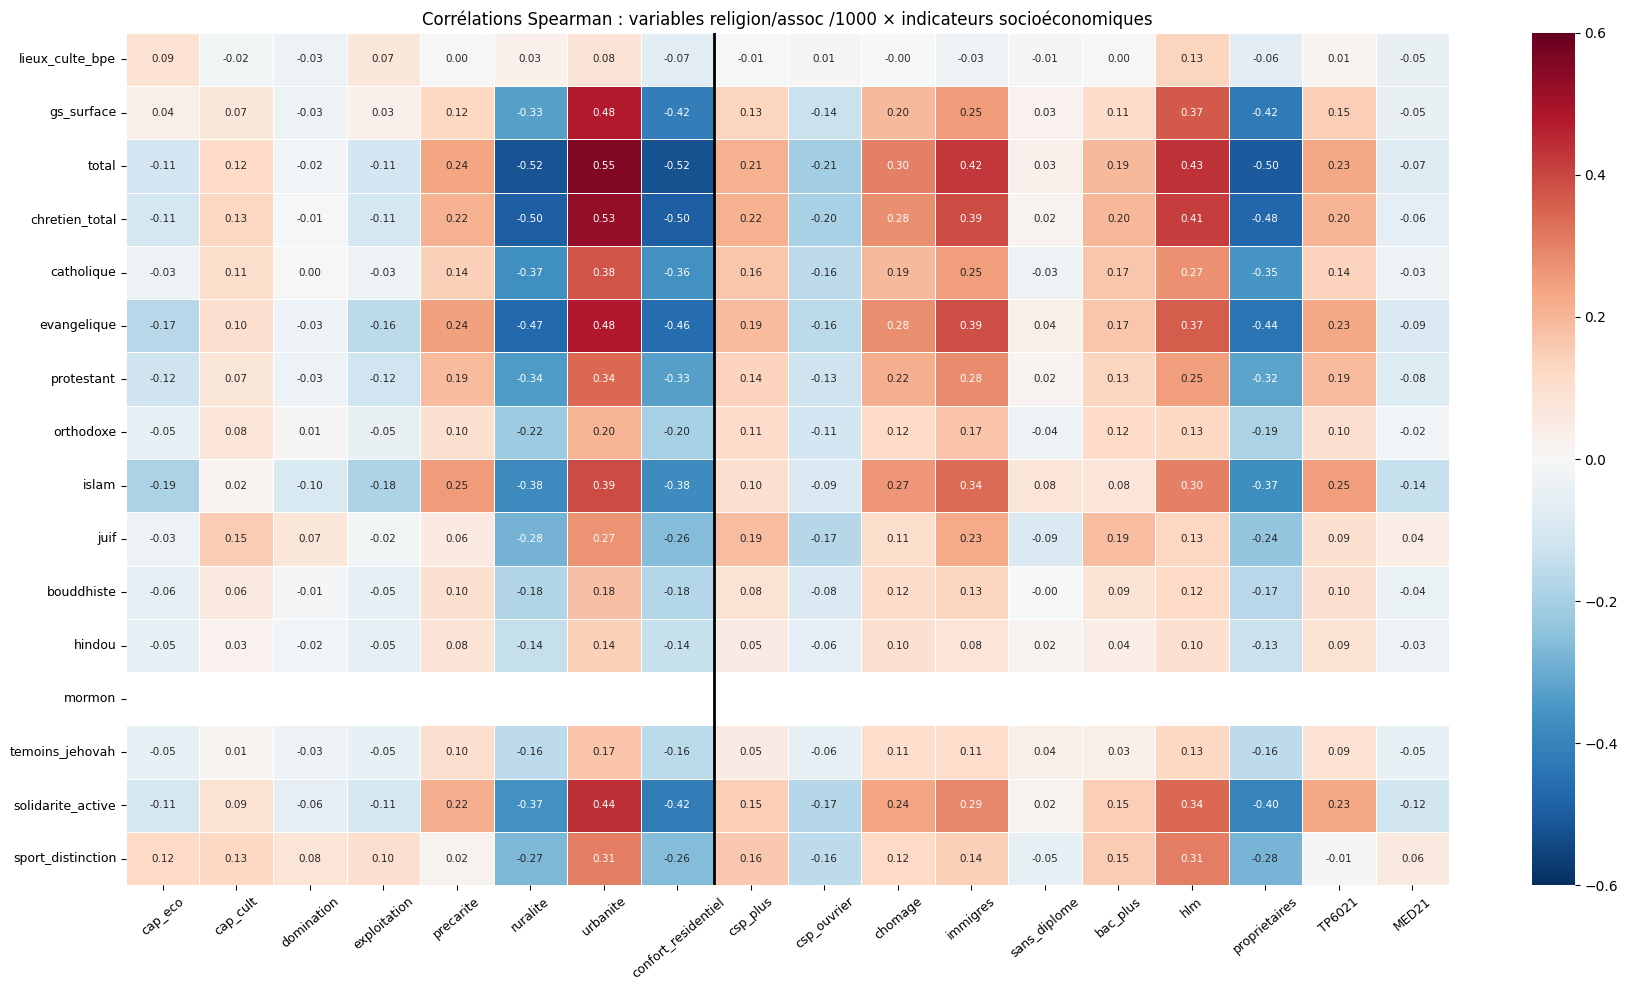

In [15]:
# ── 5. Corrélations variables /1000 × indicateurs socio ──────────────────────
socio_vars = SCORES_SOCIO + PCT_SOCIO
corr_socio = pd.DataFrame(index=POUR1000, columns=socio_vars, dtype=float)

for col in POUR1000:
    for sv in socio_vars:
        sub = df[[col, sv]].dropna()
        if len(sub) > 100:
            corr_socio.loc[col, sv] = stats.spearmanr(sub[col], sub[sv])[0]

ylabels = [c.replace('_pour1000','').replace('rna_culte_','').replace('rna_','').replace('nb_','').replace('bpe_grande_','gs_') for c in POUR1000]
xlabels  = [s.replace('score_','').replace('pct_','').replace('DISP_','') for s in socio_vars]

fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(corr_socio.astype(float), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=xlabels, yticklabels=ylabels,
            vmin=-0.6, vmax=0.6, linewidths=0.4, ax=ax, annot_kws={'size': 7.5})
ax.set_title('Corrélations Spearman : variables religion/assoc /1000 × indicateurs socioéconomiques', fontsize=12)
ax.tick_params(axis='x', rotation=40, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
# Ligne séparant scores et pct
ax.axvline(len(SCORES_SOCIO), color='black', lw=2)
plt.tight_layout()
plt.show()


## 6. Sanity checks : corrélations attendues

In [16]:
# ── 6. Sanity checks ─────────────────────────────────────────────────────────
# Hypothèses attendues :
#   rna_solidarite_active_pour1000  ↑ avec taux de pauvreté (TP6021)
#   rna_sport_distinction_pour1000  ↑ avec score_cap_eco / pct_csp_plus
#   rna_culte_islam_pour1000        ↑ avec pct_immigres
#   rna_culte_catholique_pour1000   ↑ avec score_ruralite (plus de paroisses en rural)
#   nb_lieux_culte_bpe_pour1000     ↑ avec score_urbanite

checks = [
    ('rna_solidarite_active_pour1000', 'DISP_TP6021',       'Solidarité ↑ pauvreté',     '>0'),
    ('rna_sport_distinction_pour1000', 'score_cap_eco',      'Sport distinction ↑ cap eco','>0'),
    ('rna_sport_distinction_pour1000', 'pct_csp_plus',       'Sport distinction ↑ CSP+',  '>0'),
    ('rna_culte_islam_pour1000',       'pct_immigres',        'Islam ↑ immigrés',          '>0'),
    ('rna_culte_catholique_pour1000',  'score_ruralite',      'Catholique ↑ ruralité',     '>0'),
    ('nb_lieux_culte_bpe_pour1000',    'score_urbanite',      'BPE culte ↑ urbanité',      '>0'),
    ('rna_culte_juif_pour1000',        'score_cap_eco',       'Juif ↑ cap éco',            '>0'),
    ('rna_culte_chretien_total_pour1000','pct_csp_ouvrier',   'Chrétien total ↔ ouvrier',  '?'),
]

print("Sanity checks (corrélations de Spearman):")
print(f"{'Variable A':<40} {'Variable B':<25} {'Attendu':>8} {'Observé':>8} {'n':>7} {'OK?':>4}")
print("-"*100)
for varA, varB, label, expected in checks:
    sub = df[[varA, varB]].dropna()
    rho, p = stats.spearmanr(sub[varA], sub[varB])
    ok = ''
    if expected == '>0': ok = '✓' if rho > 0.05 else '✗'
    elif expected == '<0': ok = '✓' if rho < -0.05 else '✗'
    print(f"{varA:<40} {varB:<25} {expected:>8} {rho:>+8.3f} {len(sub):>7}  {ok}  ({label})")


Sanity checks (corrélations de Spearman):
Variable A                               Variable B                 Attendu  Observé       n  OK?
----------------------------------------------------------------------------------------------------
rna_solidarite_active_pour1000           DISP_TP6021                     >0   +0.234   48079  ✓  (Solidarité ↑ pauvreté)
rna_sport_distinction_pour1000           score_cap_eco                   >0   +0.120   48079  ✓  (Sport distinction ↑ cap eco)
rna_sport_distinction_pour1000           pct_csp_plus                    >0   +0.162   48075  ✓  (Sport distinction ↑ CSP+)
rna_culte_islam_pour1000                 pct_immigres                    >0   +0.340   48079  ✓  (Islam ↑ immigrés)
rna_culte_catholique_pour1000            score_ruralite                  >0   -0.367   48079  ✗  (Catholique ↑ ruralité)
nb_lieux_culte_bpe_pour1000              score_urbanite                  >0   +0.083   48079  ✓  (BPE culte ↑ urbanité)
rna_culte_juif_pour1000       

## 7. Scatterplots détaillés : sport distinction & solidarité vs socio

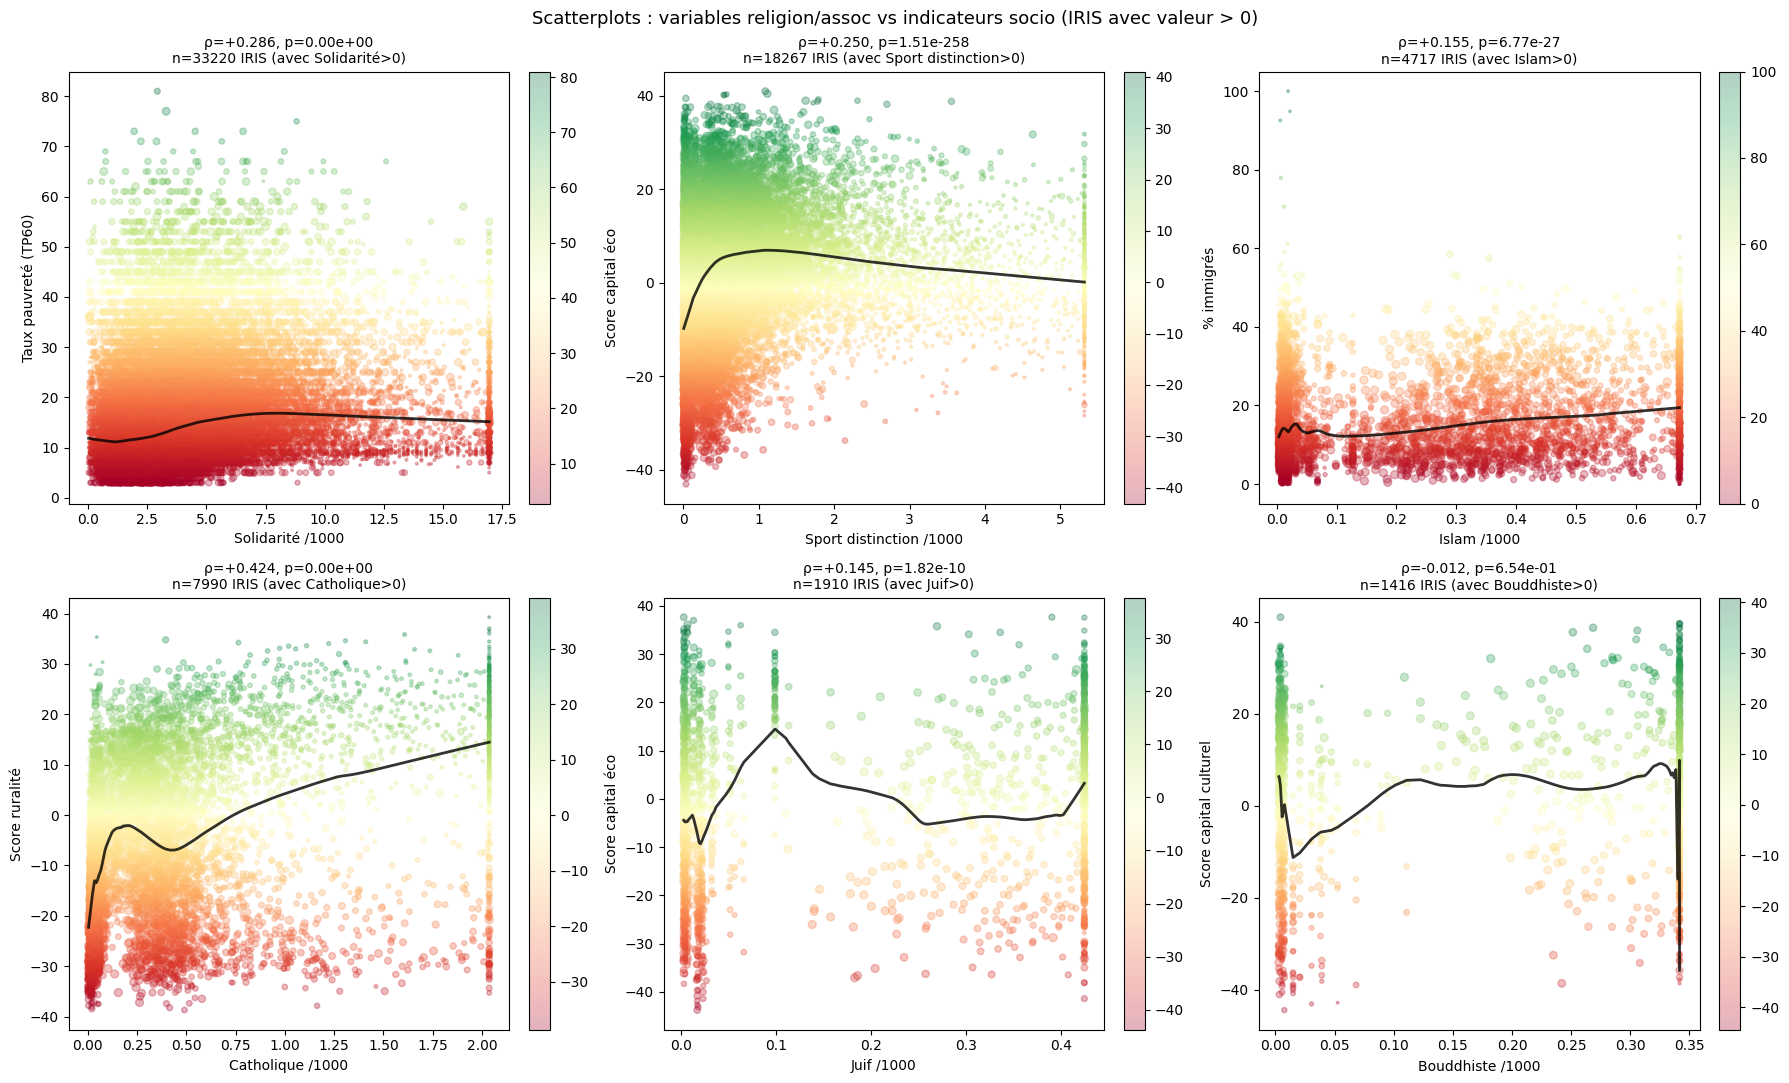

In [17]:
# ── 7. Scatterplots clés ──────────────────────────────────────────────────────
pairs = [
    ('rna_solidarite_active_pour1000', 'DISP_TP6021',    'Solidarité /1000', 'Taux pauvreté (TP60)'),
    ('rna_sport_distinction_pour1000', 'score_cap_eco',   'Sport distinction /1000', 'Score capital éco'),
    ('rna_culte_islam_pour1000',       'pct_immigres',    'Islam /1000', '% immigrés'),
    ('rna_culte_catholique_pour1000',  'score_ruralite',  'Catholique /1000', 'Score ruralité'),
    ('rna_culte_juif_pour1000',        'score_cap_eco',   'Juif /1000', 'Score capital éco'),
    ('rna_culte_bouddhiste_pour1000',  'score_cap_cult',  'Bouddhiste /1000', 'Score capital culturel'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, (xvar, yvar, xlabel, ylabel) in enumerate(pairs):
    ax = axes[i]
    sub = df[[xvar, yvar, 'pop_totale']].dropna()
    sub = sub[sub[xvar] > 0]  # seulement IRIS avec la variable > 0
    if len(sub) < 10:
        ax.text(0.5, 0.5, 'Données insuffisantes', ha='center', va='center', transform=ax.transAxes)
        continue
    rho, p = stats.spearmanr(sub[xvar], sub[yvar])
    # Scatter avec taille proportionnelle à la pop
    pop_norm = np.clip(sub['pop_totale'] / sub['pop_totale'].quantile(0.95), 0, 1)
    sc = ax.scatter(sub[xvar], sub[yvar], alpha=0.3, s=pop_norm*30+3,
                    c=sub[yvar], cmap='RdYlGn', rasterized=True)
    # Tendance (lowess-like via binning)
    try:
        from statsmodels.nonparametric.smoothers_lowess import lowess
        lo = lowess(sub[yvar].values, sub[xvar].values, frac=0.3)
        ax.plot(lo[:, 0], lo[:, 1], 'k-', lw=2, alpha=0.8)
    except Exception:
        pass
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(f'ρ={rho:+.3f}, p={p:.2e}\nn={len(sub)} IRIS (avec {xlabel.split("/")[0].strip()}>0)', fontsize=10)
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Scatterplots : variables religion/assoc vs indicateurs socio (IRIS avec valeur > 0)', fontsize=13)
plt.tight_layout()
plt.show()


## 8. Profil par type d'IRIS (urbain / périurbain / rural)

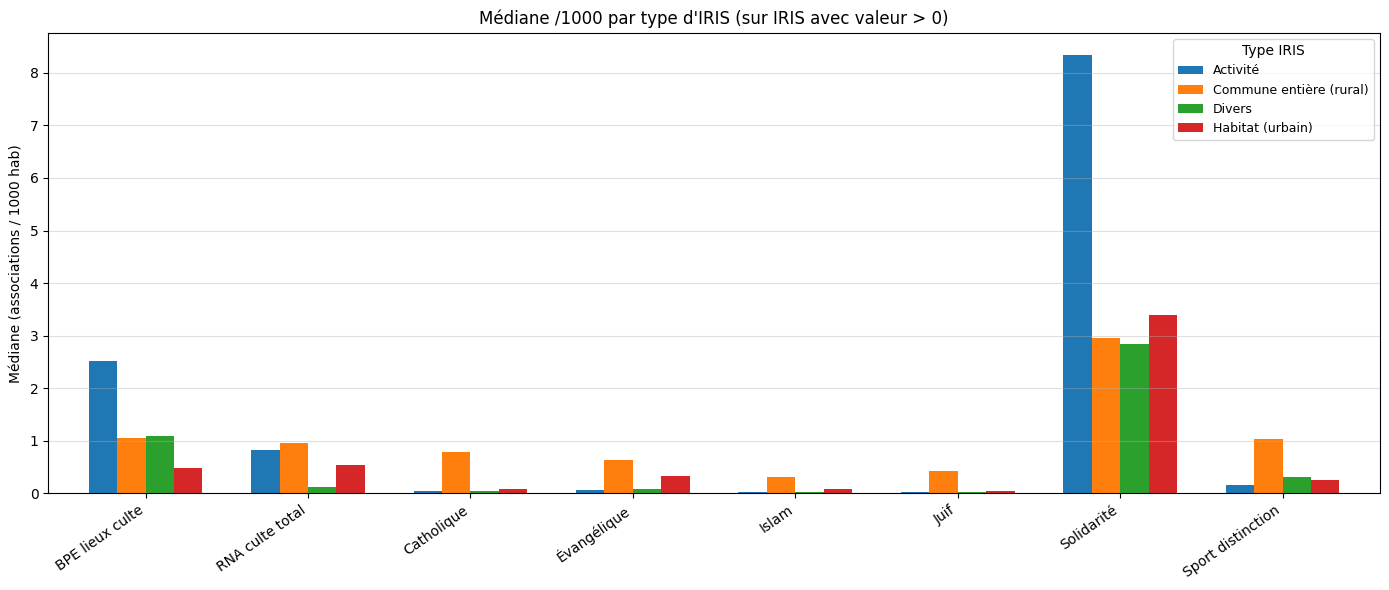


Effectifs et couverture par type d'IRIS:


,n_iris,pct_culte,pop_totale
typ_label,,,
Activité,829,64.8,495855.2
Commune entière (rural),33045,13.2,27193914.0
Divers,401,49.6,238972.8
Habitat (urbain),15005,76.1,39479310.0


In [18]:
# ── 8. Profil par TYP_IRIS ────────────────────────────────────────────────────
# TYP_IRIS : Z = ensemble commune, H = habitat, A = activité, D = divers
# On regroupe en catégories lisibles
typ_map = {'Z': 'Commune entière (rural)', 'H': 'Habitat (urbain)', 
           'A': 'Activité', 'D': 'Divers'}
df['typ_label'] = df['TYP_IRIS'].map(typ_map).fillna(df['TYP_IRIS'])

# Médianes par type (variables /1000 principales)
main_vars = ['nb_lieux_culte_bpe_pour1000', 'rna_culte_total_pour1000',
             'rna_culte_catholique_pour1000', 'rna_culte_evangelique_pour1000',
             'rna_culte_islam_pour1000', 'rna_culte_juif_pour1000',
             'rna_solidarite_active_pour1000', 'rna_sport_distinction_pour1000']

short_names = ['BPE lieux culte', 'RNA culte total', 'Catholique', 'Évangélique',
               'Islam', 'Juif', 'Solidarité', 'Sport distinction']

# Médiane sur IRIS > 0 uniquement
def median_nonzero(series): 
    v = series[series > 0]
    return v.median() if len(v) > 0 else 0

profile = df.groupby('typ_label')[main_vars].agg(median_nonzero).T
profile.index = short_names

fig, ax = plt.subplots(figsize=(14, 6))
profile.plot(kind='bar', ax=ax, width=0.7)
ax.set_title('Médiane /1000 par type d\'IRIS (sur IRIS avec valeur > 0)', fontsize=12)
ax.set_xticklabels(short_names, rotation=35, ha='right', fontsize=10)
ax.set_ylabel('Médiane (associations / 1000 hab)')
ax.legend(title='Type IRIS', fontsize=9)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# Table des effectifs par type
typ_counts = df.groupby('typ_label').agg(
    n_iris=('IRIS', 'count'),
    pct_culte=('rna_culte_total', lambda x: (x > 0).mean() * 100),
    pop_totale=('pop_totale', 'sum'),
).round(1)
print("\nEffectifs et couverture par type d'IRIS:")
display(typ_counts)


## 9. Top IRIS par variable /1000

In [19]:
# ── 9. Top 10 IRIS par variable /1000 ────────────────────────────────────────
target_vars = [
    ('rna_culte_total_pour1000',        'Total culte /1000'),
    ('rna_culte_catholique_pour1000',   'Catholique /1000'),
    ('rna_culte_islam_pour1000',        'Islam /1000'),
    ('rna_culte_juif_pour1000',         'Juif /1000'),
    ('rna_culte_evangelique_pour1000',  'Évangélique /1000'),
    ('rna_solidarite_active_pour1000',  'Solidarité /1000'),
    ('rna_sport_distinction_pour1000',  'Sport distinction /1000'),
]

for col, label in target_vars:
    top = (df[['IRIS', 'nom_commune', 'pop_totale', 'TYP_IRIS', col]]
           .dropna(subset=[col])
           .nlargest(10, col)
           [['IRIS', 'nom_commune', 'pop_totale', 'TYP_IRIS', col]])
    top[col] = top[col].round(3)
    print(f"\n{'─'*70}")
    print(f"  TOP 10 — {label}")
    print(f"{'─'*70}")
    print(top.to_string(index=False))



──────────────────────────────────────────────────────────────────────
  TOP 10 — Total culte /1000
──────────────────────────────────────────────────────────────────────
     IRIS              nom_commune  pop_totale TYP_IRIS  rna_culte_total_pour1000
021680301          Château-Thierry  141.112844        A                     5.348
024350000       Logny-lès-Aubenton   83.000000        Z                     5.348
025940000          Passy-en-Valois  126.000000        Z                     5.348
026070000                   Ploisy   91.000000        Z                     5.348
027070000                 Septvaux  179.000000        Z                     5.348
030070000 Arpheuilles-Saint-Priest  365.000000        Z                     5.348
030680000                 Châtelus  108.000000        Z                     5.348
032740000                  Sorbier  317.000000        Z                     5.348
040300000                   Blieux   54.000000        Z                     5.348
04062000

## 10. Positionnement dans l'espace sociologique (axes Polipy)

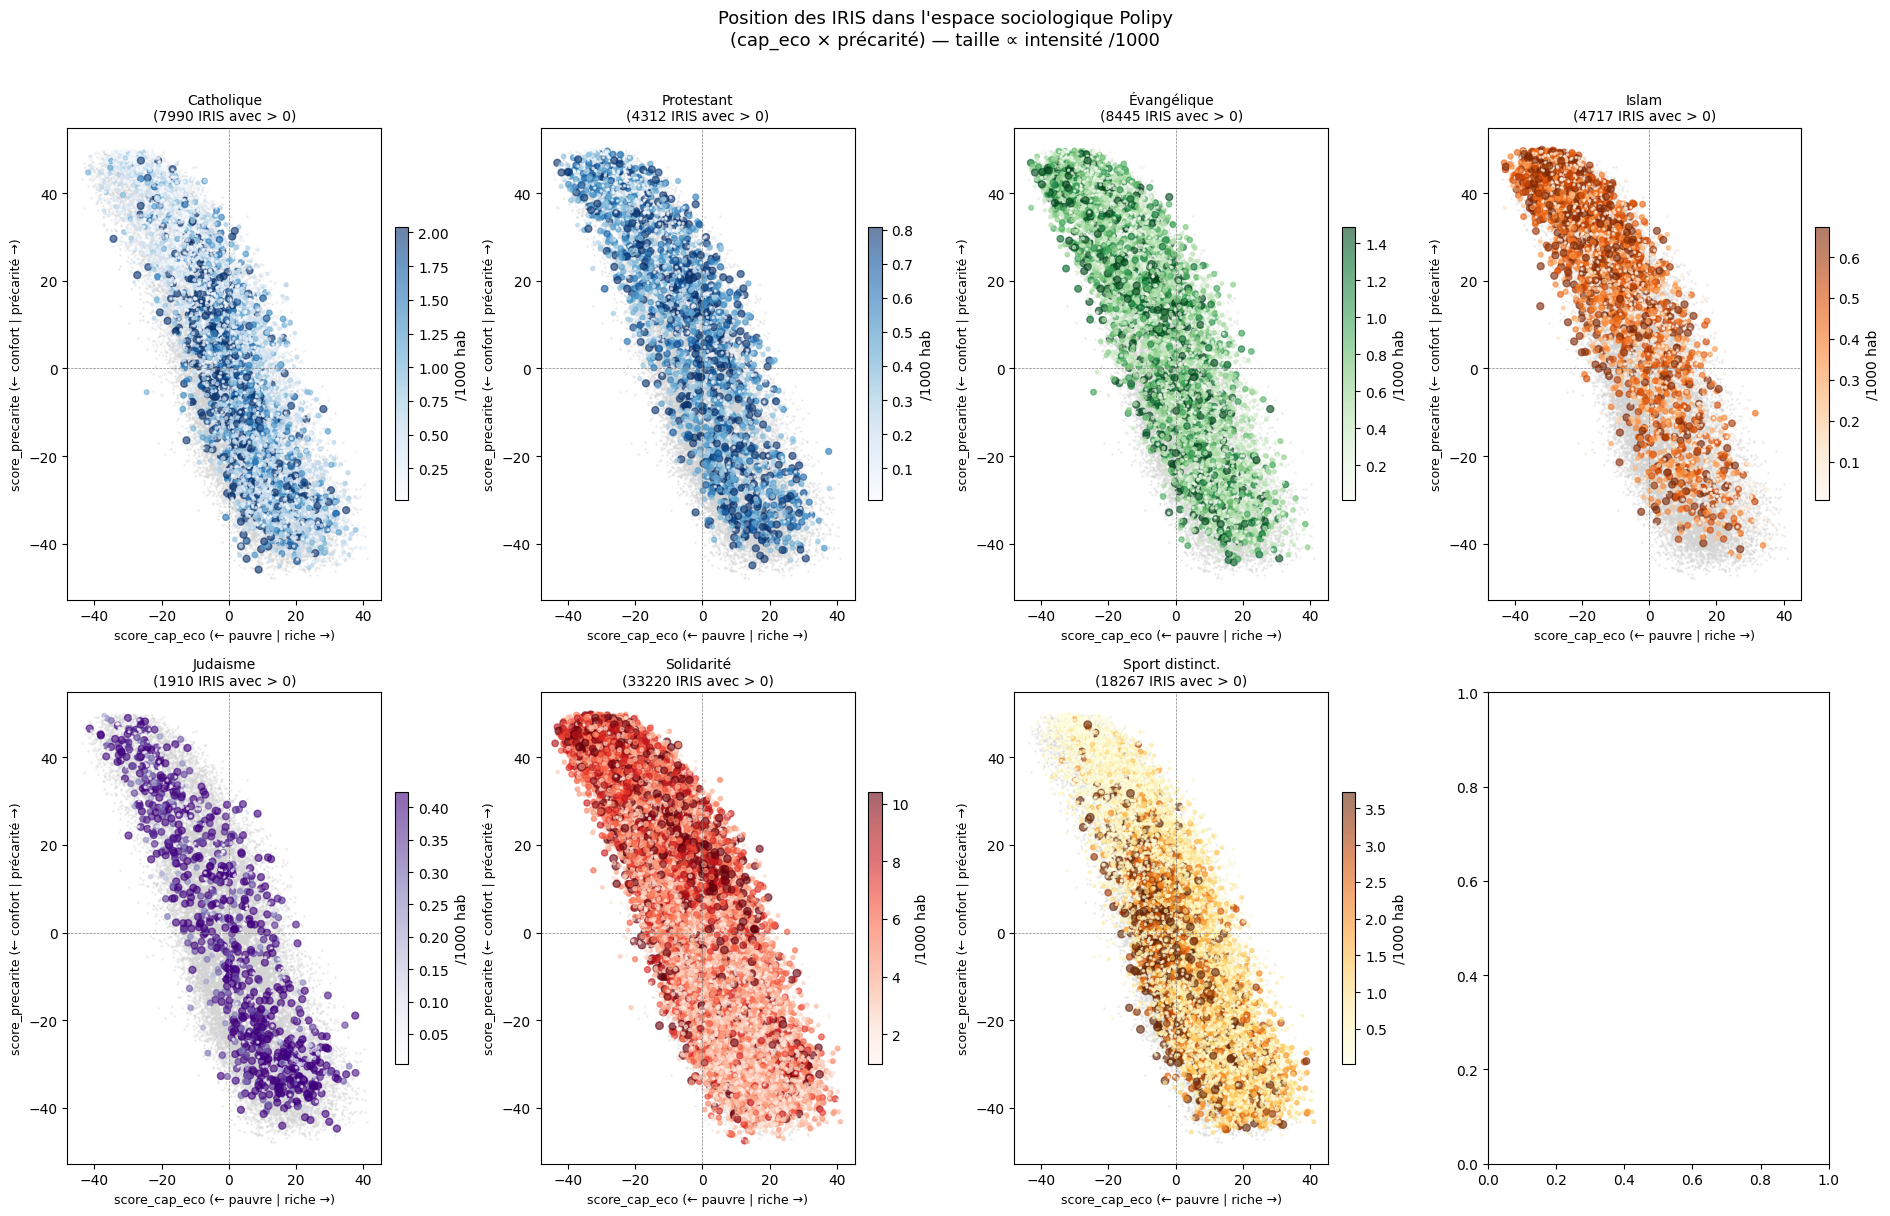

In [23]:
# ── 10. Position des IRIS "actifs" dans l'espace cap_eco × precarite ─────────
# Visualise où se concentrent les différentes religions sur les 2 axes principaux
fig, axes = plt.subplots(2, 4, figsize=(19, 12))
axes = axes.flatten()

plot_vars = [
    ('rna_culte_catholique_pour1000',  'Catholique',   'Blues'),
    ('rna_culte_protestant_pour1000',  'Protestant',   'Blues'),
    ('rna_culte_evangelique_pour1000', 'Évangélique',  'Greens'),
    ('rna_culte_islam_pour1000',       'Islam',        'Oranges'),
    ('rna_culte_juif_pour1000',        'Judaisme',         'Purples'),
    ('rna_solidarite_active_pour1000', 'Solidarité',   'Reds'),
    ('rna_sport_distinction_pour1000', 'Sport distinct.','YlOrBr'),
]

xvar, yvar = 'score_cap_eco', 'score_precarite'

for i, (col, label, cmap) in enumerate(plot_vars):
    ax = axes[i]
    base = df[[xvar, yvar, col, 'pop_totale']].dropna()
    
    # Fond : tous les IRIS en gris
    ax.scatter(base[xvar], base[yvar], s=1, c='lightgray', alpha=0.3, rasterized=True)
    
    # Overlay : IRIS avec la variable > 0, coloré par intensité
    active = base[base[col] > 0].copy()
    if len(active) > 0:
        sc = ax.scatter(active[xvar], active[yvar],
                        s=np.clip(active[col] / active[col].quantile(0.95) * 25, 2, 30),
                        c=active[col], cmap=cmap, alpha=0.6, rasterized=True,
                        norm=plt.Normalize(active[col].quantile(0.05), active[col].quantile(0.95)))
        plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.04, label='/1000 hab')
    
    ax.set_xlabel('score_cap_eco (← pauvre | riche →)', fontsize=9)
    ax.set_ylabel('score_precarite (← confort | précarité →)', fontsize=9)
    ax.set_title(f'{label}\n({len(active)} IRIS avec > 0)', fontsize=10)
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.axvline(0, color='gray', lw=0.5, ls='--')

plt.suptitle('Position des IRIS dans l\'espace sociologique Polipy\n(cap_eco × précarité) — taille ∝ intensité /1000', 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 11. Boxplots par quintile de capital économique

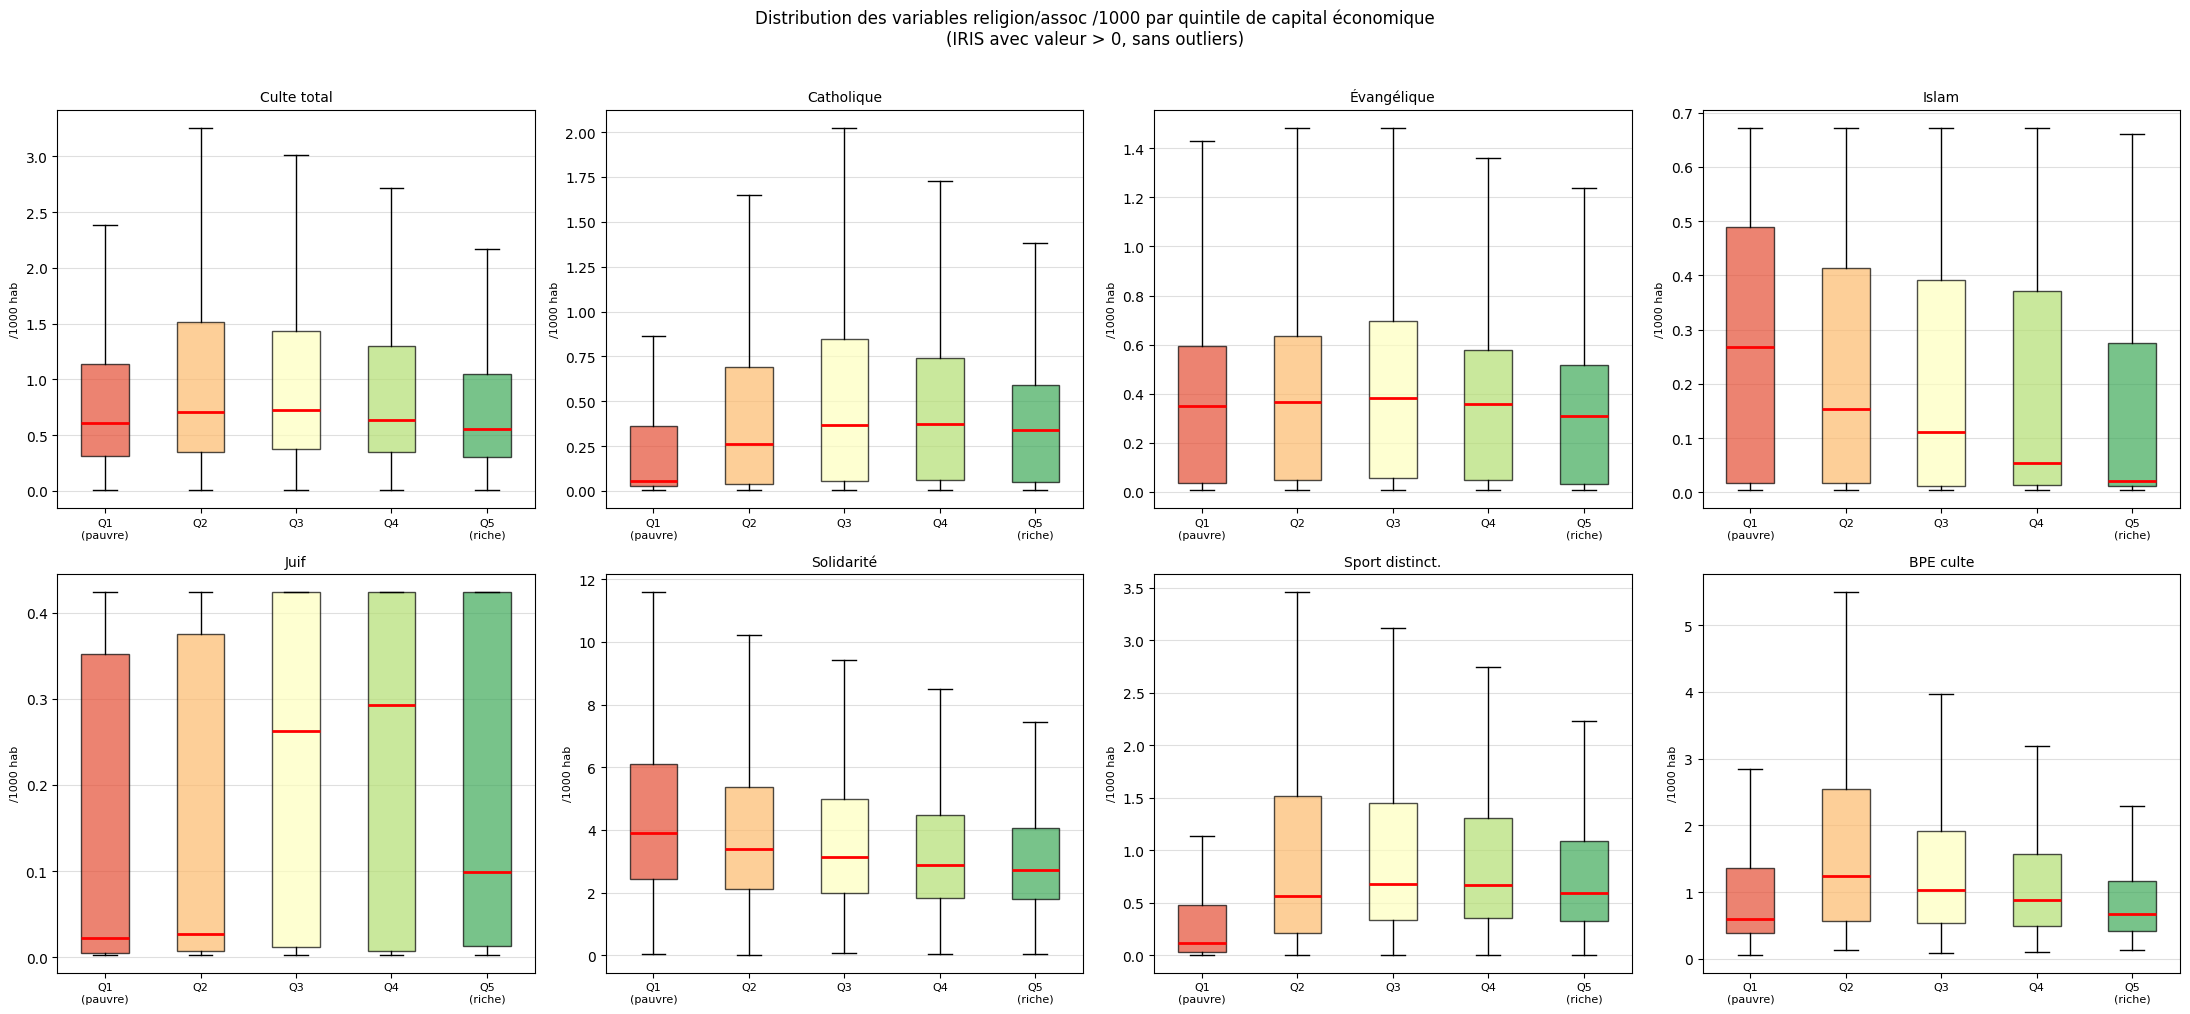

In [24]:
# ── 11. Distribution des variables /1000 par quintile de cap_eco ─────────────
df['quintile_cap_eco'] = pd.qcut(df['score_cap_eco'], q=5, labels=['Q1\n(plus pauvre)', 'Q2', 'Q3', 'Q4', 'Q5\n(plus riche)'])

vars_boxplot = [
    'rna_culte_total_pour1000', 'rna_culte_catholique_pour1000',
    'rna_culte_evangelique_pour1000', 'rna_culte_islam_pour1000',
    'rna_culte_juif_pour1000', 'rna_solidarite_active_pour1000',
    'rna_sport_distinction_pour1000', 'nb_lieux_culte_bpe_pour1000',
]
labels_bp = ['Culte total', 'Catholique', 'Évangélique', 'Islam', 
             'Juif', 'Solidarité', 'Sport distinct.', 'BPE culte']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, (col, lbl) in enumerate(zip(vars_boxplot, labels_bp)):
    ax = axes[i]
    sub = df[df[col] > 0][['quintile_cap_eco', col]].dropna()
    groups = [sub[sub['quintile_cap_eco'] == q][col].values for q in sub['quintile_cap_eco'].cat.categories]
    bp = ax.boxplot(groups, patch_artist=True, showfliers=False,
                    medianprops={'color': 'red', 'lw': 2})
    colors_q = plt.cm.RdYlGn(np.linspace(0.15, 0.85, 5))
    for patch, c in zip(bp['boxes'], colors_q):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Q1\n(pauvre)', 'Q2', 'Q3', 'Q4', 'Q5\n(riche)'], fontsize=8)
    ax.set_title(f'{lbl}', fontsize=10)
    ax.set_ylabel('/1000 hab', fontsize=8)
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Distribution des variables religion/assoc /1000 par quintile de capital économique\n(IRIS avec valeur > 0, sans outliers)', 
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 12. Cohérence BPE vs RNA — lieux de culte physiques vs associations

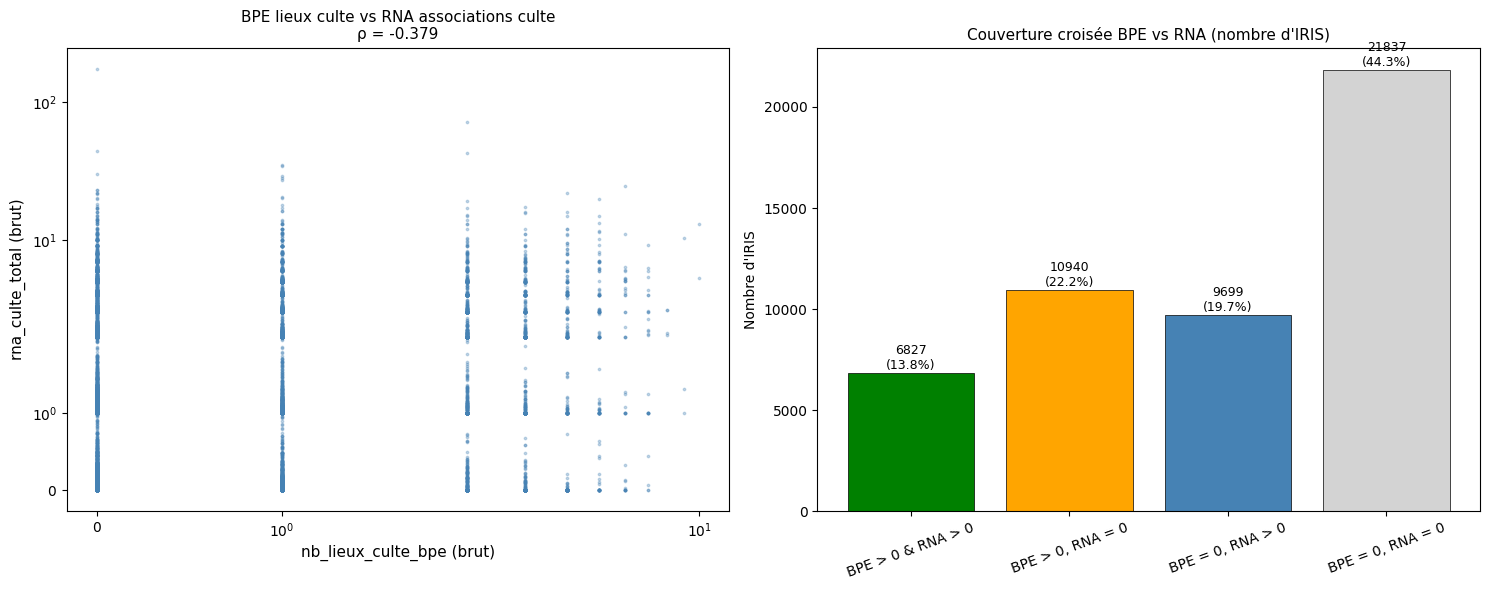


Conclusion : 10940 IRIS ont un lieu de culte BPE mais 0 association RNA
             9699 IRIS ont des associations RNA mais 0 lieu de culte BPE


In [28]:
# ── 12. BPE vs RNA : cohérence lieux de culte physiques / associations ────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter : nb_lieux_culte_bpe vs rna_culte_total
sub = df[['nb_lieux_culte_bpe', 'rna_culte_total', 'pop_totale']].dropna()
sub = sub[(sub['nb_lieux_culte_bpe'] > 0) | (sub['rna_culte_total'] > 0)]
rho, _ = stats.spearmanr(sub['nb_lieux_culte_bpe'], sub['rna_culte_total'])

axes[0].scatter(sub['nb_lieux_culte_bpe'], sub['rna_culte_total'],
                s=3, alpha=0.3, c='steelblue', rasterized=True)
axes[0].set_xlabel('nb_lieux_culte_bpe (brut)', fontsize=11)
axes[0].set_ylabel('rna_culte_total (brut)', fontsize=11)
axes[0].set_title(f'BPE lieux culte vs RNA associations culte\nρ = {rho:.3f}', fontsize=11)
axes[0].set_xscale('symlog'); axes[0].set_yscale('symlog')

# IRIS avec BPE > 0 mais RNA = 0 et inversement
has_bpe = (df['nb_lieux_culte_bpe'] > 0)
has_rna = (df['rna_culte_total'] > 0)
cats = pd.Series({
    'BPE > 0 & RNA > 0': (has_bpe & has_rna).sum(),
    'BPE > 0, RNA = 0':  (has_bpe & ~has_rna).sum(),
    'BPE = 0, RNA > 0':  (~has_bpe & has_rna).sum(),
    'BPE = 0, RNA = 0':  (~has_bpe & ~has_rna).sum(),
})
colors_cat = ['green', 'orange', 'steelblue', 'lightgray']
axes[1].bar(cats.index, cats.values, color=colors_cat, edgecolor='black', linewidth=0.5)
axes[1].set_title('Couverture croisée BPE vs RNA (nombre d\'IRIS)', fontsize=11)
axes[1].set_ylabel("Nombre d'IRIS")
for bar, val in zip(axes[1].patches, cats.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                 f'{val}\n({100*val/len(df):.1f}%)', ha='center', va='bottom', fontsize=9)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()
print(f"\nConclusion : {(has_bpe & ~has_rna).sum()} IRIS ont un lieu de culte BPE mais 0 association RNA")
print(f"             {(~has_bpe & has_rna).sum()} IRIS ont des associations RNA mais 0 lieu de culte BPE")


## 13. Taux de géocodage par département (qualité pipeline RNA)

In [26]:
# ── 13. Taux de géocodage — colonne rna_geocoding_rate ───────────────────────
if 'rna_geocoding_rate' in df.columns:
    df['dpt'] = df['IRIS'].str[:2]
    geo_by_dpt = df.groupby('dpt')['rna_geocoding_rate'].agg(['mean','count']).dropna()
    geo_by_dpt = geo_by_dpt[geo_by_dpt['count'] >= 5].sort_values('mean')
    
    fig, ax = plt.subplots(figsize=(18, 5))
    colors_geo = plt.cm.RdYlGn(geo_by_dpt['mean'].values / 100)
    bars = ax.bar(geo_by_dpt.index, geo_by_dpt['mean'], color=colors_geo, edgecolor='none')
    ax.axhline(70, color='red', ls='--', lw=1.5, label='Seuil 70%')
    ax.axhline(geo_by_dpt['mean'].mean(), color='navy', ls='-', lw=1.5, 
               label=f'Moyenne nationale : {geo_by_dpt["mean"].mean():.1f}%')
    ax.set_xlabel('Département')
    ax.set_ylabel('Taux de géocodage BAN moyen (%)')
    ax.set_title('Taux de géocodage RNA par département (moyenne des IRIS)')
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f"\nDépartements sous 70% : {(geo_by_dpt['mean'] < 70).sum()}")
    print(f"Départements au-dessus 90% : {(geo_by_dpt['mean'] >= 90).sum()}")
    print(f"Taux moyen national : {geo_by_dpt['mean'].mean():.1f}%")
else:
    print("Colonne 'rna_geocoding_rate' absente du dataset (elle est calculée mais pas dans la sortie actuelle).")
    print("Variables disponibles:", [c for c in df.columns if 'geo' in c.lower()])


Colonne 'rna_geocoding_rate' absente du dataset (elle est calculée mais pas dans la sortie actuelle).
Variables disponibles: []


---
# PARTIE II — Analyse politique × religion

## 15. Chargement des données électorales


In [32]:
# ── 15. Chargement élections + construction dataset enrichi ──────────────────
ELEC_DIR = 'iris/elections'

def load_elec(fname, rename_iris='CODE_IRIS'):
    path = f'{ELEC_DIR}/{fname}'
    e = pd.read_csv(path, dtype={rename_iris: str}, low_memory=False)
    e[rename_iris] = e[rename_iris].str.zfill(9)
    e = e.rename(columns={rename_iris: 'IRIS'})
    return e

pres22_t1 = load_elec('2022_pres_t1.csv')
pres22_t2 = load_elec('2022_pres_t2.csv')
leg24_t1  = load_elec('2024_legi_t1.csv')
leg24_t2  = load_elec('2024_legi_t2.csv')
eur24_t1  = load_elec('2024_euro_t1.csv')

# Suffixer les colonnes pour éviter les collisions
def suffix(df, suf, keep='IRIS'):
    return df.rename(columns={c: f'{c}_{suf}' for c in df.columns if c != keep})

p22t1 = suffix(pres22_t1, 'p22t1')
p22t2 = suffix(pres22_t2, 'p22t2')
l24t1 = suffix(leg24_t1,  'l24t1')
l24t2 = suffix(leg24_t2,  'l24t2')
e24t1 = suffix(eur24_t1,  'e24t1')

# Merge sur df (déjà socio+religion)
dfe = (df
       .merge(p22t1, on='IRIS', how='left')
       .merge(p22t2, on='IRIS', how='left')
       .merge(l24t1, on='IRIS', how='left')
       .merge(l24t2, on='IRIS', how='left')
       .merge(e24t1, on='IRIS', how='left'))

print(f"Dataset enrichi : {dfe.shape[0]} IRIS × {dfe.shape[1]} colonnes")

# Résumé rapide des variables électorales clés
elec_summary = {
    'Pres T1 LE_PEN':     dfe['score_LE_PEN_p22t1'].describe(),
    'Pres T1 MELENCHON':  dfe['score_MELENCHON_p22t1'].describe(),
    'Pres T1 MACRON':     dfe['score_MACRON_p22t1'].describe(),
    'Pres T1 ZEMMOUR':    dfe['score_ZEMMOUR_p22t1'].describe(),
    'Pres T2 LE_PEN':     dfe['score_LE_PEN_p22t2'].describe(),
    'Pres T2 MACRON':     dfe['score_MACRON_p22t2'].describe(),
    'Leg T1 RN':          dfe['score_RN_l24t1'].describe(),
    'Leg T1 NFP':         dfe['score_NFP_l24t1'].describe(),
    'Leg T2 RN':          dfe['score_RN_l24t2'].describe(),
    'Leg T2 NFP':         dfe['score_NFP_l24t2'].describe(),
    'Euro T1 RN':         dfe['score_RN_e24t1'].describe(),
}
pd.DataFrame(elec_summary).T[['mean','std','50%','min','max']].round(2)


Dataset enrichi : 49303 IRIS × 660 colonnes


,mean,std,50%,min,max
Pres T1 LE_PEN,26.13,10.63,26.18,0.0,78.00
Pres T1 MELENCHON,20.27,11.42,17.44,0.0,91.03
Pres T1 MACRON,25.66,7.50,25.21,0.0,77.46
Pres T1 ZEMMOUR,6.86,3.35,6.42,0.0,47.83
Pres T2 LE_PEN,45.99,13.97,47.34,0.0,100.00
Pres T2 MACRON,54.01,13.97,52.66,0.0,100.00
Leg T1 RN,33.35,17.99,36.04,0.0,100.00
Leg T1 NFP,25.50,14.94,22.88,0.0,93.42
Leg T2 RN,36.78,20.74,41.32,0.0,96.15
Leg T2 NFP,22.91,25.77,0.00,0.0,100.00


In [35]:
eur24_t1.columns

Index(['IRIS', 'inscrits', 'votants', 'abstentions', 'blancs', 'nuls',
       'exprimes', 'RN', 'REC', 'EXD', 'LR', 'DVD', 'ENS', 'PS_PP', 'LFI',
       'DVG', 'EELV', 'PCF', 'EXG', 'AUTRE', 'score_RN', 'score_REC',
       'score_EXD', 'score_LR', 'score_DVD', 'score_ENS', 'score_PS_PP',
       'score_LFI', 'score_DVG', 'score_EELV', 'score_PCF', 'score_EXG',
       'score_AUTRE', 'pct_abstention', 'score_blanc', 'score_nul'],
      dtype='object')

## 16. Corrélations religion × vote — matrice complète (contrôlée et brute)

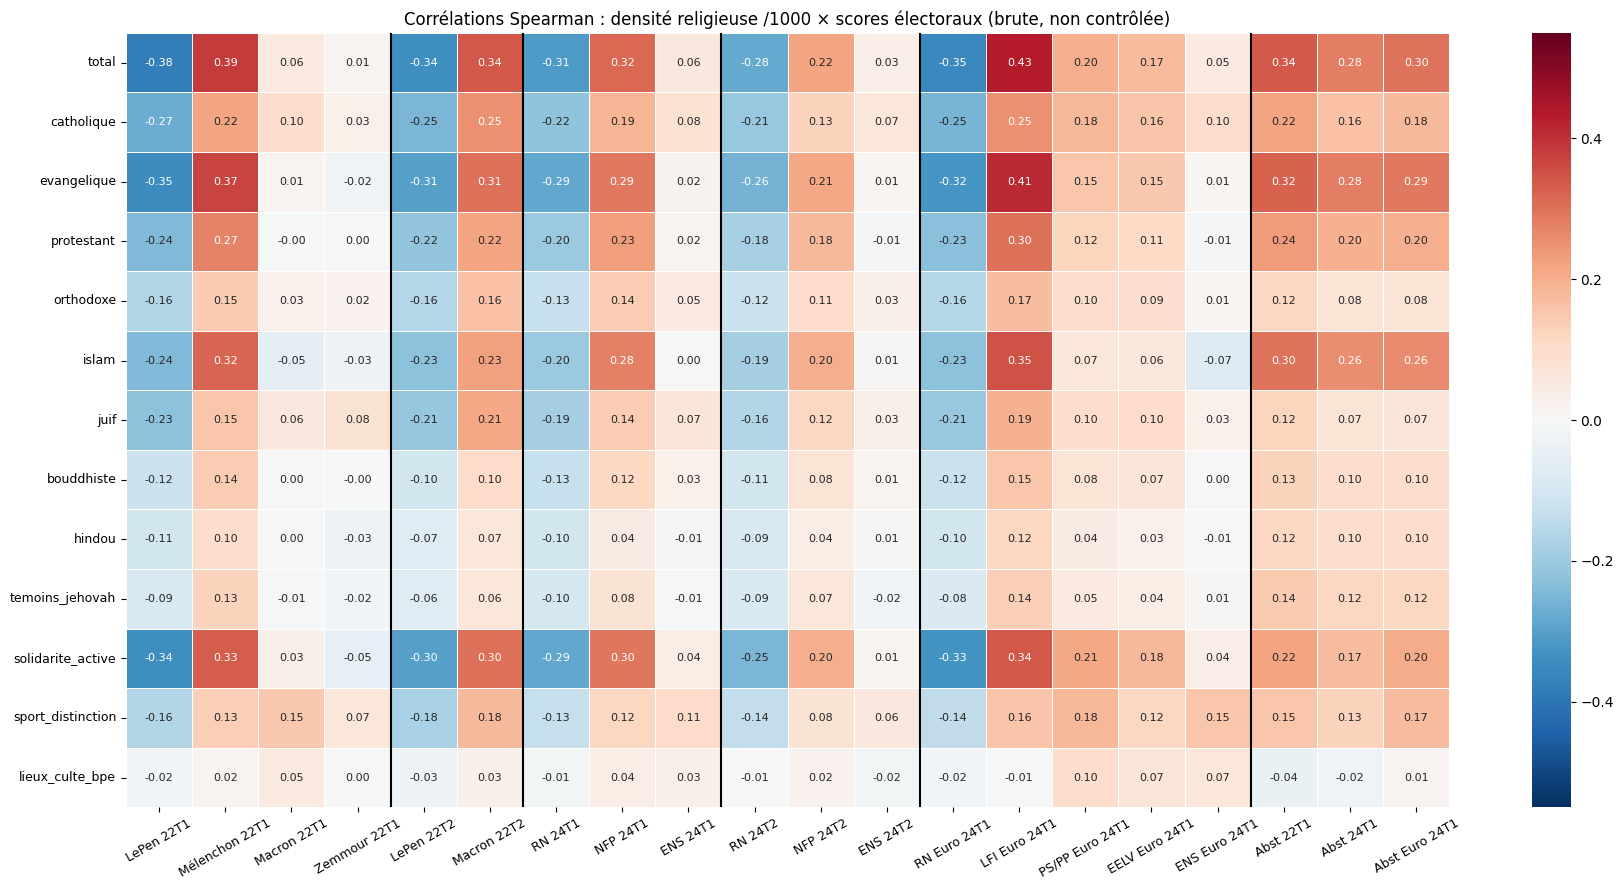

In [37]:
# ── 16. Heatmap corrélations religion × vote ─────────────────────────────────
# Colonnes religion (brut pour éviter les NaN de la normalisation)
REL_VARS = [
    'rna_culte_total_pour1000', 'rna_culte_catholique_pour1000',
    'rna_culte_evangelique_pour1000', 'rna_culte_protestant_pour1000',
    'rna_culte_orthodoxe_pour1000', 'rna_culte_islam_pour1000',
    'rna_culte_juif_pour1000', 'rna_culte_bouddhiste_pour1000',
    'rna_culte_hindou_pour1000', 'rna_culte_temoins_jehovah_pour1000',
    'rna_solidarite_active_pour1000', 'rna_sport_distinction_pour1000',
    'nb_lieux_culte_bpe_pour1000',
]
VOTE_VARS = [
    ('score_LE_PEN_p22t1',    'LePen 22T1'),
    ('score_MELENCHON_p22t1', 'Mélenchon 22T1'),
    ('score_MACRON_p22t1',    'Macron 22T1'),
    ('score_ZEMMOUR_p22t1',   'Zemmour 22T1'),
    ('score_LE_PEN_p22t2',    'LePen 22T2'),
    ('score_MACRON_p22t2',    'Macron 22T2'),
    ('score_RN_l24t1',        'RN 24T1'),
    ('score_NFP_l24t1',       'NFP 24T1'),
    ('score_ENS_l24t1',       'ENS 24T1'),
    ('score_RN_l24t2',        'RN 24T2'),
    ('score_NFP_l24t2',       'NFP 24T2'),
    ('score_ENS_l24t2',       'ENS 24T2'),
    ('score_RN_e24t1',        'RN Euro 24T1'),
    ('score_LFI_e24t1',       'LFI Euro 24T1'),
    ('score_PS_PP_e24t1',       'PS/PP Euro 24T1'),
    ('score_EELV_e24t1',      'EELV Euro 24T1'),
    ('score_ENS_e24t1',       'ENS Euro 24T1'),
    ('pct_abstention_p22t1',  'Abst 22T1'),
    ('pct_abstention_l24t1',  'Abst 24T1'),
    ('pct_abstention_e24t1',  'Abst Euro 24T1'),
]
vote_cols  = [v for v, _ in VOTE_VARS]
vote_lbls  = [l for _, l in VOTE_VARS]
rel_lbls   = [c.replace('_pour1000','').replace('rna_culte_','').replace('rna_','').replace('nb_','') for c in REL_VARS]

corr_rv = pd.DataFrame(index=REL_VARS, columns=vote_cols, dtype=float)
for r in REL_VARS:
    for v in vote_cols:
        sub = dfe[[r, v]].dropna()
        if len(sub) > 200:
            corr_rv.loc[r, v] = stats.spearmanr(sub[r], sub[v])[0]

fig, ax = plt.subplots(figsize=(18, 9))
sns.heatmap(corr_rv.astype(float), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=vote_lbls, yticklabels=rel_lbls,
            vmin=-0.55, vmax=0.55, linewidths=0.4, ax=ax, annot_kws={'size': 8})
ax.set_title('Corrélations Spearman : densité religieuse /1000 × scores électoraux (brute, non contrôlée)', fontsize=12)
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
# Séparateur T1/T2 pres vs leg
ax.axvline(4, color='black', lw=1.5)
ax.axvline(6, color='black', lw=1.5)
ax.axvline(9, color='black', lw=1.5)
ax.axvline(12, color='black', lw=1.5)
ax.axvline(17, color='black', lw=1.5)
plt.tight_layout()
plt.show()


## 17. Corrélations partielles religion × vote (contrôle : cap_eco + précarité + pct_immigres)

> Pour savoir s'il y a un **effet propre** de la densité religieuse sur le vote, indépendamment du profil socio-économique de l'IRIS.

Calcul des corrélations partielles (résidus OLS)...


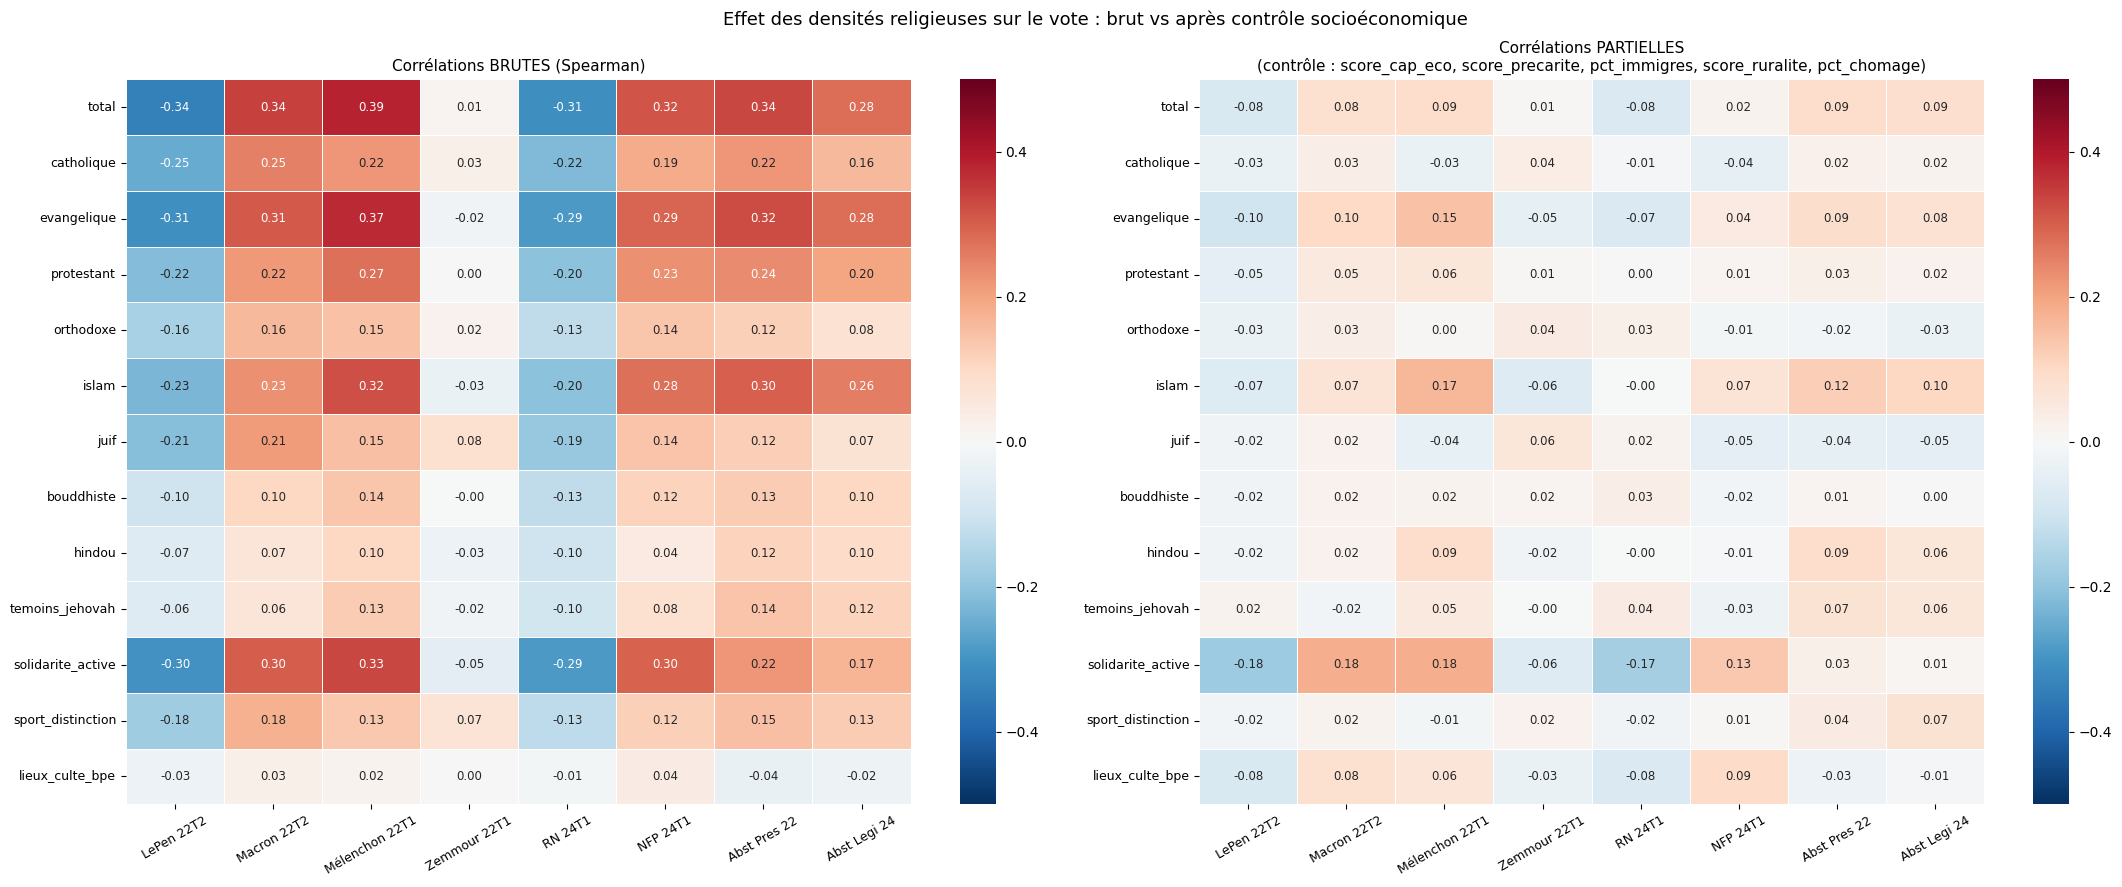


Interprétation : les cellules qui restent colorées dans la colonne 'partielle'
indiquent un effet propre de la variable religieuse, non expliqué par le profil socio.


In [38]:
# ── 17. Corrélations partielles religion × vote (résidus OLS) ─────────────────
# Méthode : régresser X et Y sur les covariables, prendre les résidus, puis corréler.
# Covariables de contrôle : cap_eco, précarité, pct_immigres, ruralité, pct_chomage
from numpy.linalg import lstsq

CONTROLS = ['score_cap_eco', 'score_precarite', 'pct_immigres', 'score_ruralite', 'pct_chomage']

def partial_spearman(df_sub, x_col, y_col, controls):
    """Corrélation de Spearman sur les résidus OLS après contrôle."""
    cols_needed = [x_col, y_col] + controls
    sub = df_sub[cols_needed].dropna()
    if len(sub) < 200:
        return np.nan
    Z = np.column_stack([np.ones(len(sub))] + [sub[c].values for c in controls])
    def resid(col):
        y = sub[col].values
        coef, *_ = lstsq(Z, y, rcond=None)
        return y - Z @ coef
    rx = resid(x_col)
    ry = resid(y_col)
    return stats.spearmanr(rx, ry)[0]

# Focus sur votes clés
VOTE_SEL = [
    ('score_LE_PEN_p22t2',    'LePen 22T2'),
    ('score_MACRON_p22t2',    'Macron 22T2'),
    ('score_MELENCHON_p22t1', 'Mélenchon 22T1'),
    ('score_ZEMMOUR_p22t1',   'Zemmour 22T1'),
    ('score_RN_l24t1',        'RN 24T1'),
    ('score_NFP_l24t1',       'NFP 24T1'),
    ('pct_abstention_p22t1',  'Abst Pres 22'),
    ('pct_abstention_l24t1',  'Abst Legi 24'),
]
vs_cols = [v for v,_ in VOTE_SEL]
vs_lbls = [l for _,l in VOTE_SEL]

# Calcul : brut vs partiel côte à côte
print("Calcul des corrélations partielles (résidus OLS)...")
corr_partial = pd.DataFrame(index=REL_VARS, columns=vs_cols, dtype=float)
corr_brute2  = pd.DataFrame(index=REL_VARS, columns=vs_cols, dtype=float)

for r in REL_VARS:
    for v in vs_cols:
        sub2 = dfe[[r, v]].dropna()
        if len(sub2) > 200:
            corr_brute2.loc[r, v] = stats.spearmanr(sub2[r], sub2[v])[0]
        corr_partial.loc[r, v] = partial_spearman(dfe, r, v, CONTROLS)

# Affichage côte à côte : brut vs partiel
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for ax, data, title in [
    (axes[0], corr_brute2,  'Corrélations BRUTES (Spearman)'),
    (axes[1], corr_partial, f'Corrélations PARTIELLES\n(contrôle : {", ".join(CONTROLS)})'),
]:
    sns.heatmap(data.astype(float), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                xticklabels=vs_lbls, yticklabels=rel_lbls,
                vmin=-0.5, vmax=0.5, linewidths=0.4, ax=ax, annot_kws={'size': 8.5})
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.suptitle('Effet des densités religieuses sur le vote : brut vs après contrôle socioéconomique', fontsize=13)
plt.tight_layout()
plt.show()

print("\nInterprétation : les cellules qui restent colorées dans la colonne 'partielle'")
print("indiquent un effet propre de la variable religieuse, non expliqué par le profil socio.")


## 18. Scatterplots détaillés religion × vote avec densité (kde overlay)

> Chaque point = 1 IRIS. Couleur = parti dominant. Contours KDE = zones de forte densité.

In [ ]:
# ── 18. Scatter religion × vote avec overlay KDE ─────────────────────────────
# Paires : (var_religion, var_vote, titre)
scatter_pairs = [
    ('rna_culte_islam_pour1000',       'score_MELENCHON_p22t1', 'Islam /1000 × Mélenchon T1'),
    ('rna_culte_islam_pour1000',       'score_LE_PEN_p22t2',    'Islam /1000 × Le Pen T2'),
    ('rna_culte_islam_pour1000',       'score_NFP_l24t1',       'Islam /1000 × NFP Legi 24T1'),
    ('rna_culte_islam_pour1000',       'score_RN_l24t1',        'Islam /1000 × RN Legi 24T1'),
    ('rna_culte_catholique_pour1000',  'score_LE_PEN_p22t2',    'Catholique /1000 × Le Pen T2'),
    ('rna_culte_catholique_pour1000',  'score_MACRON_p22t2',    'Catholique /1000 × Macron T2'),
    ('rna_culte_evangelique_pour1000', 'score_RN_l24t1',        'Évangélique /1000 × RN 24T1'),
    ('rna_culte_evangelique_pour1000', 'score_NFP_l24t1',       'Évangélique /1000 × NFP 24T1'),
    ('rna_culte_juif_pour1000',        'score_MACRON_p22t2',    'Juif /1000 × Macron T2'),
    ('rna_culte_juif_pour1000',        'score_LE_PEN_p22t2',    'Juif /1000 × Le Pen T2'),
    ('rna_solidarite_active_pour1000', 'score_MELENCHON_p22t1', 'Solidarité /1000 × Mélenchon T1'),
    ('rna_sport_distinction_pour1000', 'score_MACRON_p22t2',    'Sport dist. /1000 × Macron T2'),
]

ncols = 4
nrows = (len(scatter_pairs) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 5))
axes = axes.flatten()

for i, (xvar, yvar, title) in enumerate(scatter_pairs):
    ax = axes[i]
    sub = dfe[[xvar, yvar, 'pop_totale']].dropna()
    # Seulement les IRIS avec variable relig > 0
    sub_nz = sub[sub[xvar] > 0].copy()
    
    if len(sub_nz) < 30:
        ax.text(0.5, 0.5, 'n < 30', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontsize=9)
        continue

    rho_all, _ = stats.spearmanr(sub[xvar].fillna(0), sub[yvar])
    rho_nz,  _ = stats.spearmanr(sub_nz[xvar], sub_nz[yvar])

    # Scatter (tous les IRIS, ceux à 0 en gris)
    ax.scatter(sub[sub[xvar] == 0][xvar], sub[sub[xvar] == 0][yvar],
               s=2, alpha=0.15, c='lightgray', rasterized=True, zorder=1)
    
    # Scatter non-zéro coloré par intensité relig
    sc = ax.scatter(sub_nz[xvar], sub_nz[yvar],
                    s=np.clip(sub_nz['pop_totale'] / sub_nz['pop_totale'].quantile(0.95) * 15, 2, 20),
                    c=sub_nz[xvar], cmap='YlOrRd', alpha=0.5, rasterized=True, zorder=2,
                    norm=plt.Normalize(0, sub_nz[xvar].quantile(0.95)))
    
    # KDE sur les IRIS non-zéro (contours)
    if len(sub_nz) >= 50:
        try:
            sns.kdeplot(x=sub_nz[xvar], y=sub_nz[yvar], ax=ax,
                        levels=4, color='navy', linewidths=0.8, alpha=0.7, zorder=3)
        except Exception:
            pass

    # Tendance lowess
    try:
        from statsmodels.nonparametric.smoothers_lowess import lowess
        lo = lowess(sub_nz[yvar].values, sub_nz[xvar].values, frac=0.4)
        ax.plot(lo[:, 0], lo[:, 1], 'k-', lw=2, zorder=4)
    except Exception:
        pass

    ax.set_xlabel(xvar.replace('_pour1000','').replace('rna_culte_','').replace('rna_',''), fontsize=8)
    ax.set_ylabel(yvar.replace('score_','').replace('_p22t1','').replace('_p22t2','').replace('_l24t1',''), fontsize=8)
    ax.set_title(f'{title}\nρ(tous)={rho_all:+.3f}  ρ(>0 seul)={rho_nz:+.3f}  n={len(sub_nz)}', fontsize=8.5)
    plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.02, label='densité')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Scatter religion /1000 × score electoral\n(gris = IRIS à 0, coloré = IRIS avec asso, contours KDE, courbe Lowess)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 19. IRIS sur axe islam × catholique, coloré par vote

In [ ]:
# ── 19. Espace islam × catholique coloré par vote ────────────────────────────
# Restreindre aux IRIS avec au moins une des deux variables > 0
# On visualise ainsi le "spectre confessionnel" en 2D et son lien politique

vote_color_vars = [
    ('score_LE_PEN_p22t2',    'Le Pen T2 2022 (%)',    'RdBu_r',  (20, 80)),
    ('score_MACRON_p22t2',    'Macron T2 2022 (%)',    'RdBu',    (20, 80)),
    ('score_MELENCHON_p22t1', 'Mélenchon T1 2022 (%)', 'PuOr_r',  (5, 45)),
    ('score_RN_l24t1',        'RN Legi 24T1 (%)',      'Reds',    (0, 55)),
    ('score_NFP_l24t1',       'NFP Legi 24T1 (%)',     'Blues',   (0, 50)),
    ('pct_abstention_p22t1',  'Abstention Pres 22 (%)', 'Greens', (15, 45)),
]

xvar = 'rna_culte_islam_pour1000'
yvar = 'rna_culte_catholique_pour1000'

ncols = 3
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(21, 13))
axes = axes.flatten()

for i, (vcol, vlabel, cmap, (vmin, vmax)) in enumerate(vote_color_vars):
    ax = axes[i]
    sub = dfe[[xvar, yvar, vcol, 'pop_totale']].dropna()
    # Limiter aux IRIS avec au moins un culte > 0
    sub = sub[(sub[xvar] > 0) | (sub[yvar] > 0)]
    
    if len(sub) < 50:
        ax.set_visible(False); continue
    
    sc = ax.scatter(sub[xvar], sub[yvar],
                    c=sub[vcol], cmap=cmap,
                    s=np.clip(sub['pop_totale'] / sub['pop_totale'].quantile(0.95) * 20, 2, 25),
                    alpha=0.55, vmin=vmin, vmax=vmax, rasterized=True)
    
    # KDE pour l'axe X élevé (beaucoup de mosquées)
    sub_islam = sub[sub[xvar] > sub[xvar].quantile(0.75)]
    sub_catho = sub[sub[yvar] > sub[yvar].quantile(0.75)]
    if len(sub_islam) >= 30:
        try:
            sns.kdeplot(x=sub_islam[xvar], y=sub_islam[yvar], ax=ax,
                        levels=3, color='darkorange', linewidths=1.2, alpha=0.8, label='Top 25% islam')
        except Exception: pass
    if len(sub_catho) >= 30:
        try:
            sns.kdeplot(x=sub_catho[xvar], y=sub_catho[yvar], ax=ax,
                        levels=3, color='darkblue', linewidths=1.2, alpha=0.8, linestyles='--', label='Top 25% catho')
        except Exception: pass
    
    plt.colorbar(sc, ax=ax, label=vlabel)
    ax.set_xlabel('Islam /1000 hab', fontsize=10)
    ax.set_ylabel('Catholique /1000 hab', fontsize=10)
    ax.set_title(f'{vlabel}', fontsize=11)
    ax.legend(fontsize=8, loc='upper right')
    
    # Annotations quadrants
    xmed, ymed = sub[xvar].median(), sub[yvar].median()
    # ax.axvline(xmed, color='gray', lw=0.5, ls=':')
    # ax.axhline(ymed, color='gray', lw=0.5, ls=':')

plt.suptitle('Espace confessionnel Islam × Catholique — couleur = score électoral\n(taille ∝ population IRIS)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 20. Densités KDE 2D : concentration des votes dans l'espace confessionnel

> Pour chaque parti, les zones d'intensité de vote **conditionnellement à la présence** d'une communauté religieuse.

In [ ]:
# ── 20. KDE 2D : vote selon la densité islamique et catholique ────────────────
# Pour chaque parti, on découpe les IRIS par tercile de densité confessionnelle
# et on trace la KDE du vote dans chaque groupe

fig, axes = plt.subplots(3, 4, figsize=(22, 16))

religion_groups = [
    ('rna_culte_islam_pour1000',      'Islam',      'Oranges'),
    ('rna_culte_catholique_pour1000', 'Catholique', 'Blues'),
    ('rna_culte_evangelique_pour1000','Évangélique','Greens'),
]
vote_pairs = [
    ('score_LE_PEN_p22t2',    'Le Pen T2', '#c0392b'),
    ('score_MACRON_p22t2',    'Macron T2', '#f39c12'),
    ('score_MELENCHON_p22t1', 'Mélenchon', '#8e44ad'),
    ('score_RN_l24t1',        'RN 24T1',   '#e74c3c'),
]

for row, (rvar, rlabel, rcmap) in enumerate(religion_groups):
    for col, (vvar, vlabel, vcolor) in enumerate(vote_pairs):
        ax = axes[row][col]
        sub = dfe[[rvar, vvar]].dropna()
        sub_pos = sub[sub[rvar] > 0]
        
        # Terciles de densité religieuse (parmi IRIS avec la variable > 0)
        if len(sub_pos) < 60:
            ax.set_visible(False); continue
        
        q33, q66 = sub_pos[rvar].quantile(0.33), sub_pos[rvar].quantile(0.66)
        g1 = sub_pos[sub_pos[rvar] <= q33][vvar]   # faible densité
        g2 = sub_pos[(sub_pos[rvar] > q33) & (sub_pos[rvar] <= q66)][vvar]  # moyen
        g3 = sub_pos[sub_pos[rvar] > q66][vvar]    # forte densité
        
        # KDE des scores de vote pour chaque tercile
        for g, label, alpha, ls in [
            (g1, 'Faible densité', 0.5, '--'),
            (g2, 'Densité moyenne', 0.7, ':'),
            (g3, 'Forte densité', 1.0, '-'),
        ]:
            if len(g) >= 20:
                g.plot.kde(ax=ax, label=f'{label} (n={len(g)})', alpha=alpha, 
                          linestyle=ls, color=vcolor, linewidth=1.8)
        
        # Médianes par groupe
        for g, ls in [(g1,'--'), (g2,':'), (g3,'-')]:
            if len(g) >= 5:
                ax.axvline(g.median(), color=vcolor, lw=0.8, ls=ls, alpha=0.5)
        
        ax.set_xlabel(f'{vlabel} (%)', fontsize=9)
        ax.set_title(f'{rlabel} × {vlabel}', fontsize=9.5)
        ax.legend(fontsize=7, loc='upper right')
        ax.set_xlim(0, 100)
        ax.grid(alpha=0.3)
        
        # Test Kruskal-Wallis
        try:
            groups_clean = [g for g in [g1, g2, g3] if len(g) >= 5]
            if len(groups_clean) == 3:
                _, p_kw = stats.kruskal(*groups_clean)
                ax.text(0.02, 0.97, f'KW p={p_kw:.3f}', transform=ax.transAxes,
                        fontsize=7, va='top', color='black',
                        fontweight='bold' if p_kw < 0.05 else 'normal')
        except Exception:
            pass

plt.suptitle('KDE du vote par tercile de densité confessionnelle\n(terciles calculés parmi les IRIS avec ≥1 asso)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 21. Espace Polipy (cap_eco × précarité) coloré par vote, avec densité islamique en taille

In [ ]:
# ── 21. Espace Polipy × vote × religion (taille = densité confessionnelle) ───
# cap_eco × precarite, couleur = score vote, taille = densité islamique ou catholique

configs = [
    # (religion_var, label_relig, vote_var, vote_label, cmap, vmin, vmax)
    ('rna_culte_islam_pour1000',      'Islam /1000',      'score_LE_PEN_p22t2',    'Le Pen T2',     'RdBu_r', 25, 75),
    ('rna_culte_islam_pour1000',      'Islam /1000',      'score_MELENCHON_p22t1', 'Mélenchon T1',  'PuOr_r', 5, 40),
    ('rna_culte_catholique_pour1000', 'Catholique /1000', 'score_LE_PEN_p22t2',    'Le Pen T2',     'RdBu_r', 25, 75),
    ('rna_culte_catholique_pour1000', 'Catholique /1000', 'score_MACRON_p22t2',    'Macron T2',     'RdBu',   25, 75),
    ('rna_culte_islam_pour1000',      'Islam /1000',      'score_RN_l24t1',        'RN 24T1',       'Reds',   0, 50),
    ('rna_culte_islam_pour1000',      'Islam /1000',      'score_NFP_l24t1',       'NFP 24T1',      'Blues',  0, 50),
]

fig, axes = plt.subplots(2, 3, figsize=(21, 13))
axes = axes.flatten()

for i, (rvar, rlabel, vvar, vlabel, cmap, vmin, vmax) in enumerate(configs):
    ax = axes[i]
    needed = ['score_cap_eco', 'score_precarite', rvar, vvar, 'pop_totale']
    sub = dfe[needed].dropna()
    sub_all  = sub.copy()
    sub_relig = sub[sub[rvar] > 0].copy()
    
    # Fond : tous les IRIS, petits points gris
    ax.scatter(sub_all['score_cap_eco'], sub_all['score_precarite'],
               s=1, c='#e0e0e0', alpha=0.4, rasterized=True, zorder=1)
    
    # Overlay : IRIS avec religion > 0, couleur = vote, taille = densité relig
    if len(sub_relig) >= 20:
        size_norm = np.clip(sub_relig[rvar] / sub_relig[rvar].quantile(0.95) * 60, 4, 80)
        sc = ax.scatter(sub_relig['score_cap_eco'], sub_relig['score_precarite'],
                        c=sub_relig[vvar], cmap=cmap, s=size_norm,
                        alpha=0.65, vmin=vmin, vmax=vmax, rasterized=True, zorder=2)
        plt.colorbar(sc, ax=ax, label=f'{vlabel} (%)')
    
    # KDE de la zone à forte densité relig
    if len(sub_relig) >= 50:
        top_relig = sub_relig[sub_relig[rvar] > sub_relig[rvar].quantile(0.7)]
        if len(top_relig) >= 30:
            try:
                sns.kdeplot(x=top_relig['score_cap_eco'], y=top_relig['score_precarite'],
                            ax=ax, levels=4, color='black', linewidths=0.9, alpha=0.7, zorder=3)
            except Exception: pass
    
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.axvline(0, color='gray', lw=0.5, ls='--')
    ax.set_xlabel('score_cap_eco (← pauvre | riche →)', fontsize=9)
    ax.set_ylabel('score_precarite (← confort | précarité →)', fontsize=9)
    ax.set_title(f'Taille = {rlabel}  |  Couleur = {vlabel}\n(contours = top 30% densité relig)', fontsize=9.5)

plt.suptitle('Espace sociologique Polipy (cap_eco × précarité)\ntaille = densité confessionnelle, couleur = score électoral', 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 22. Profil électoral moyen par quartile de densité confessionnelle

In [ ]:
# ── 22. Profil électoral par quartile de densité confessionnelle ──────────────
# Pour chaque religion, montrer comment évoluent les scores de TOUS les partis
# quand on passe du quartile 1 (faible densité) au quartile 4 (forte densité)
# (uniquement parmi les IRIS avec la variable > 0)

vote_profile_vars = [
    ('score_LE_PEN_p22t1',    'LePen T1', '#c0392b'),
    ('score_MELENCHON_p22t1', 'Mélen T1', '#8e44ad'),
    ('score_MACRON_p22t1',    'Macron T1', '#f39c12'),
    ('score_ZEMMOUR_p22t1',   'Zemmour T1', '#e67e22'),
    ('score_LE_PEN_p22t2',    'LePen T2', '#922b21'),
    ('score_MACRON_p22t2',    'Macron T2', '#d35400'),
    ('score_RN_l24t1',        'RN 24T1',  '#e74c3c'),
    ('score_NFP_l24t1',       'NFP 24T1', '#2980b9'),
    ('pct_abstention_p22t1',  'Abst 22T1', '#7f8c8d'),
]
vp_cols  = [c for c,_,_ in vote_profile_vars]
vp_lbls  = [l for _,l,_ in vote_profile_vars]
vp_colors= [c for _,_,c in vote_profile_vars]

religions_profil = [
    ('rna_culte_islam_pour1000',       'Islam',       '#e67e22'),
    ('rna_culte_catholique_pour1000',  'Catholique',  '#2980b9'),
    ('rna_culte_evangelique_pour1000', 'Évangélique', '#27ae60'),
    ('rna_culte_juif_pour1000',        'Juif',        '#8e44ad'),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
axes = axes.flatten()

for i, (rvar, rlabel, rcolor) in enumerate(religions_profil):
    ax = axes[i]
    sub = dfe[[rvar] + vp_cols].dropna()
    sub = sub[sub[rvar] > 0]
    
    if len(sub) < 80:
        ax.text(0.5, 0.5, 'n insuffisant', ha='center', va='center', transform=ax.transAxes)
        continue
    
    sub['_quartile'] = pd.qcut(sub[rvar], q=4, labels=['Q1\n(faible)', 'Q2', 'Q3', 'Q4\n(forte)'])
    profile_q = sub.groupby('_quartile')[vp_cols].median()
    profile_q.columns = vp_lbls
    
    # Normaliser par rapport à Q1 pour voir les écarts
    profile_delta = profile_q - profile_q.iloc[0]
    
    x = np.arange(len(vp_lbls))
    width = 0.18
    for j, (q_label, row_vals) in enumerate(profile_delta.iterrows()):
        offset = (j - 1.5) * width
        bars = ax.bar(x + offset, row_vals.values, width, label=q_label, alpha=0.75,
                     color=plt.cm.RdYlGn(j / 3))
    
    ax.axhline(0, color='black', lw=0.8, ls='-')
    ax.set_xticks(x); ax.set_xticklabels(vp_lbls, rotation=30, ha='right', fontsize=8.5)
    ax.set_ylabel('Écart médian vs Q1 (points de %)', fontsize=9)
    ax.set_title(f'Profil électoral — {rlabel} (densité /1000)\n'
                 f'Δ par rapport au Q1 (faible densité), n={len(sub)} IRIS', fontsize=10)
    ax.legend(title='Quartile densité', fontsize=8, ncol=2)
    ax.grid(axis='y', alpha=0.3)
    
    # Nombre d'IRIS par quartile
    counts = sub.groupby('_quartile').size()
    for j, (q, n) in enumerate(counts.items()):
        ax.text(j * 0.25 - 0.1, ax.get_ylim()[0] * 0.95, f'n={n}', fontsize=7, color='gray')

plt.suptitle('Profil électoral médian par quartile de densité confessionnelle\n(Δ vs Q1 = quartile de faible densité, sur IRIS avec ≥1 asso)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 23. Densités KDE 2D dans l'espace cap_eco × précarité par religion

In [ ]:
# ── 23. KDE 2D superposées religions dans l'espace socio Polipy ───────────────
# Montre visuellement où "vit" chaque communauté religieuse dans l'espace Polipy

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

religions_kde = [
    ('rna_culte_islam_pour1000',       'Islam',       'Oranges',    'darkorange',  '-'),
    ('rna_culte_catholique_pour1000',  'Catholique',  'Blues',      'steelblue',   '-'),
    ('rna_culte_evangelique_pour1000', 'Évangélique', 'Greens',     'darkgreen',   '--'),
    ('rna_culte_juif_pour1000',        'Juif',        'Purples',    'purple',      ':'),
    ('rna_culte_bouddhiste_pour1000',  'Bouddhiste',  'Reds',       'firebrick',   '-.'),
]

# Axe 1 : cap_eco × précarité (axes Polipy principaux)
ax1 = axes[0]
ax1.scatter(dfe['score_cap_eco'], dfe['score_precarite'], s=1, c='#eeeeee', alpha=0.3, rasterized=True)
for rvar, rlabel, _, color, ls in religions_kde:
    sub = dfe[['score_cap_eco', 'score_precarite', rvar]].dropna()
    top = sub[sub[rvar] > sub[rvar].quantile(0.75)]  # top 25% densité
    if len(top) >= 40:
        try:
            sns.kdeplot(x=top['score_cap_eco'], y=top['score_precarite'], ax=ax1,
                        levels=4, color=color, linewidths=2, linestyles=ls,
                        alpha=0.85, label=f'{rlabel} (top 25%, n={len(top)})')
        except Exception: pass
ax1.axhline(0, color='gray', lw=0.5, ls='--'); ax1.axvline(0, color='gray', lw=0.5, ls='--')
ax1.set_xlabel('score_cap_eco (← pauvre | riche →)', fontsize=10)
ax1.set_ylabel('score_precarite (← confort | précarité →)', fontsize=10)
ax1.set_title('Densités KDE : où se situent les IRIS\nà forte densité confessionnelle (top 25%)', fontsize=11)
ax1.legend(fontsize=9)

# Axe 2 : ruralité × domination
ax2 = axes[1]
ax2.scatter(dfe['score_ruralite'], dfe['score_domination'], s=1, c='#eeeeee', alpha=0.3, rasterized=True)
for rvar, rlabel, _, color, ls in religions_kde:
    sub = dfe[['score_ruralite', 'score_domination', rvar]].dropna()
    top = sub[sub[rvar] > sub[rvar].quantile(0.75)]
    if len(top) >= 40:
        try:
            sns.kdeplot(x=top['score_ruralite'], y=top['score_domination'], ax=ax2,
                        levels=4, color=color, linewidths=2, linestyles=ls,
                        alpha=0.85, label=f'{rlabel} (top 25%, n={len(top)})')
        except Exception: pass
ax2.axhline(0, color='gray', lw=0.5, ls='--'); ax2.axvline(0, color='gray', lw=0.5, ls='--')
ax2.set_xlabel('score_ruralite (← urbain | rural →)', fontsize=10)
ax2.set_ylabel('score_domination', fontsize=10)
ax2.set_title('Densités KDE : ruralité × domination\npour les mêmes IRIS à forte densité', fontsize=11)
ax2.legend(fontsize=9)

plt.suptitle('Où se concentrent les différentes communautés religieuses dans l\'espace sociologique ?\n'
             '(contours KDE sur IRIS avec densité > 75e percentile)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 24. Analyse de médiation : la religion est-elle un médiateur ou un confondu du vote ?

> On compare la corrélation brute `pct_immigres → vote` avec et sans contrôle de `islam_pour1000`, pour tester si la densité islamique capte quelque chose au-delà du fait d'être immigré.

In [ ]:
# ── 24. Islam /1000 : médiateur ou confondu avec pct_immigres ? ──────────────
# Test : corrélation islam → vote, avec et sans contrôle de pct_immigres
# Si la corr partielle (contrôlant les immigrés) reste forte → effet propre de la densité asso
# Si elle disparaît → la densité islamique capte surtout la présence d'immigrés

VOTE_TEST = [
    ('score_LE_PEN_p22t2',    'Le Pen T2'),
    ('score_MACRON_p22t2',    'Macron T2'),
    ('score_MELENCHON_p22t1', 'Mélenchon T1'),
    ('score_RN_l24t1',        'RN 24T1'),
    ('score_NFP_l24t1',       'NFP 24T1'),
    ('pct_abstention_p22t1',  'Abst Pres 22'),
]

results = []
for vvar, vlabel in VOTE_TEST:
    cols = ['rna_culte_islam_pour1000', vvar, 'pct_immigres', 'score_cap_eco', 'score_precarite']
    sub = dfe[cols].dropna()
    sub = sub[sub['rna_culte_islam_pour1000'] > 0]
    if len(sub) < 100:
        continue
    
    # Brut
    rho_brut, p_brut = stats.spearmanr(sub['rna_culte_islam_pour1000'], sub[vvar])
    
    # Partiel contrôlant pct_immigres uniquement
    rho_ctrl_imm = partial_spearman(sub, 'rna_culte_islam_pour1000', vvar, ['pct_immigres'])
    
    # Partiel contrôlant immigres + socio
    rho_ctrl_full = partial_spearman(sub, 'rna_culte_islam_pour1000', vvar,
                                     ['pct_immigres', 'score_cap_eco', 'score_precarite'])
    
    results.append({
        'Vote': vlabel,
        'ρ brut': round(rho_brut, 3),
        'ρ (- immigrés)': round(rho_ctrl_imm, 3),
        'ρ (- immigrés - socio)': round(rho_ctrl_full, 3),
        'n IRIS': len(sub),
    })

result_df = pd.DataFrame(results).set_index('Vote')
print("Islam /1000 → vote : corrélations avec et sans contrôle")
print("(sur IRIS avec >0 asso islamique)\n")
display(result_df.style
        .background_gradient(cmap='RdBu_r', subset=['ρ brut', 'ρ (- immigrés)', 'ρ (- immigrés - socio)'], vmin=-0.5, vmax=0.5)
        .format('{:.3f}', subset=['ρ brut', 'ρ (- immigrés)', 'ρ (- immigrés - socio)'])
)

print("\nInterprétation :")
print("  Si ρ(- immigrés) >> ρ brut  → islam/1000 capte qqch au-delà de la simple présence d'immigrés")
print("  Si ρ(- immigrés) ≈ 0        → la relation est entièrement médiée par la composition ethnique")
